# 📊 Model Comparison — Churn Prediction
## Customer Churn & LTV Engine

This notebook follows a professional ML validation workflow:
1. Setup & Data Loading
2. Overfitting Check (validate models are healthy)
3. Model Comparison (compare validated models)
4. Final Conclusion 

## Importing Data:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.append("../src")

from feature_engineering import create_features
from model_comparision import compare_churn_models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("✅ All imports successful")

✅ All imports successful


## Loading Data:

In [2]:
df = pd.read_csv("../data/ecommerce_user_segmentation.csv")
df = create_features(df)

# Drop unnecessary columns
for col in ["Customer_ID", "Segment_Label", "Recency"]:
    if col in df.columns:
        df = df.drop(col, axis=1)

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("✅ Data loaded successfully")
print(f"   Dataset shape  : {df.shape}")
print(f"   Features       : {X.shape[1]}")
print(f"   Churn Rate     : {y.mean()*100:.1f}%")

✅ Data loaded successfully
   Dataset shape  : (10000, 18)
   Features       : 17
   Churn Rate     : 10.7%


### ⚠️ Class Imbalance Warning

Churn rate is **10.7%** — meaning our dataset is imbalanced.

| Class | Count | Percentage |
|-------|-------|------------|
| Not Churned (0) | ~89% | Majority |
| Churned (1) | ~10.7% | Minority ← what we care about |

This means:
- A model predicting "no churn" for everyone gets **89% accuracy for free**
- **Accuracy becomes a misleading metric**
- We must rely on **F1 Score and ROC-AUC** instead
- We are applying **class balancing** to help the model learn churners better

## Code to(Visualize Imbalance):

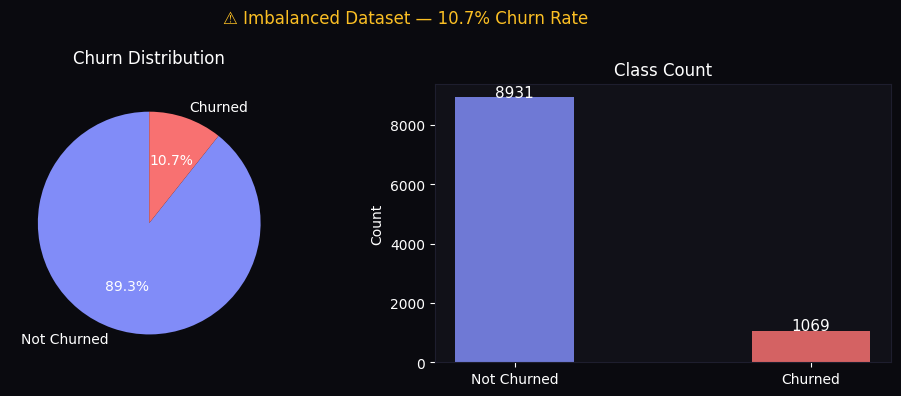

Not Churned : 8931 (89.3%)
Churned     : 1069 (10.7%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor("#0a0a0f")

counts = y.value_counts()
labels = ["Not Churned", "Churned"]
colors = ["#818cf8", "#f87171"]

# Pie chart
ax1 = axes[0]
ax1.set_facecolor("#0a0a0f")
ax1.pie(counts, labels=labels, colors=colors, autopct="%1.1f%%",
        textprops={"color": "white"}, startangle=90)
ax1.set_title("Churn Distribution", color="white", pad=15)

# Bar chart
ax2 = axes[1]
ax2.set_facecolor("#111118")
bars = ax2.bar(labels, counts, color=colors, alpha=0.85, width=0.4)
ax2.set_title("Class Count", color="white")
ax2.tick_params(colors="white")
ax2.set_ylabel("Count", color="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e1e2e")
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha="center", color="white", fontsize=11)

plt.suptitle("⚠️ Imbalanced Dataset — 10.7% Churn Rate",
             color="#fbbf24", fontsize=12)
plt.tight_layout()
plt.savefig("../notebooks/class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Not Churned : {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Churned     : {counts[1]} ({counts[1]/len(y)*100:.1f}%)")

### 📋 Class Imbalance Insights

- **Severe imbalance detected** — 8,931 non-churners vs only 1,069 churners (8.3:1 ratio).
  A model predicting "no churn" for everyone would score **89.3% accuracy without learning anything useful**.

- **Accuracy is unreliable here** — With only 10.7% churners, we must use
  **F1 Score and ROC-AUC** as primary metrics since they account for this imbalance.

- **Solution** — We will use XGBoost  `scale_pos_weight=8.35` and 
  RandomForest/LightGBM .
   `class_weight=balanced` to force models to 
  treat each churner as **8x more important** during training.

### 💡 Why Class Balancing Even With Low Churn?

Simple Real World Example
Imagine you have 100 students in a class:
  90 students → Pass ✅
  10 students → Fail ❌
Now you build a model to predict who will fail.
The lazy model says:
"I'll predict EVERYONE passes"
Result → 90% accuracy 🎉

But it MISSED all 10 failing students ❌
Same thing with my data:
Model says "nobody will churn" 
→ gets 89.3% accuracy automatically
→ but misses ALL 1,069 churners
→ company loses $534,500 in revenue

Low churn (10.7%) is GOOD for business — but BAD for ML models.

**Without balancing:**
- Model predicts "no churn" for everyone
- Gets 89.3% accuracy automatically  
- Misses ALL real churners
- Company loses ~$534,500/year undetected

**With balancing (scale_pos_weight=8.35):**
- Model treats each churner as 8x more important
- Learns the rare but costly patterns
- Catches real churners before they leave
- Enables targeted retention campaigns

Think of it like a smoke detector —


Think of class balancing like a smoke detector - 
Fire happens only 0.1% of the time — very rare.
But you still want the detector to be VERY sensitive to smoke.
You don't want it saying "probably no fire" 99.9% of the time.
Class balancing makes your model sensitive to rare but costly events — just like a smoke detector.

### Business Translation
10.7% churn sounds small BUT:

10,000 customers
× 10.7% churning
= 1,069 customers leaving

× $500 average spend per customer
= $534,500 lost revenue per year

That's HALF A MILLION DOLLARS
Even saving 30% of them =
$160,000 retained revenue

## Fixing Imbalance with Class_Weight:
- `class_weight=balanced` to force models to 
  treat each churner as **8x more important** during training.

In [4]:
# Fixing imbalance by telling models to pay more attention to churners
models = {
    "RandomForest" : RandomForestClassifier(
                        n_estimators=100, 
                        random_state=42,
                        class_weight="balanced"   # ← fixes imbalance
                    ),
    "XGBoost"      : XGBClassifier(
                        eval_metric="logloss",
                        random_state=42,
                        verbosity=0,
                        scale_pos_weight=counts[0]/counts[1]  # ← fixes imbalance
                    ),
    "LightGBM"     : LGBMClassifier(
                        random_state=42,
                        verbose=-1,
                        class_weight="balanced"   # ← fixes imbalance
                    ),
}

print("✅ Models configured with class balancing")
print(f"   XGBoost scale_pos_weight : {counts[0]/counts[1]:.2f}")
print(f"   RF & LightGBM            : class_weight = balanced")

✅ Models configured with class balancing
   XGBoost scale_pos_weight : 8.35
   RF & LightGBM            : class_weight = balanced


## 🔄 Model Comparison With Class Balancing Applied
Re-running all 3 models with balancing fix and comparing results.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

balanced_results = []
balanced_trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    balanced_results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "F1 Score" : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4),
    })
    balanced_trained[name] = model
    print(f"  {name} trained ✅")

balanced_df = pd.DataFrame(balanced_results).sort_values("ROC-AUC", ascending=False)
balanced_df

  RandomForest trained ✅
  XGBoost trained ✅
  LightGBM trained ✅


,Model,Accuracy,F1 Score,ROC-AUC
1,XGBoost,0.9660,0.8547,0.9846
0,RandomForest,0.9635,0.8403,0.9830
2,LightGBM,0.9695,0.8742,0.9826


## Before vs After Balncing Table:

In [6]:
print("=" * 60)
print("   BEFORE vs AFTER CLASS BALANCING — F1 SCORE COMPARISON")
print("=" * 60)

# Before scores (from your original run)
before = {
    "XGBoost"      : 0.8214,
    "RandomForest" : 0.8649,
    "LightGBM"     : 0.8204,
}

for _, row in balanced_df.iterrows():
    name       = row["Model"]
    after_f1   = row["F1 Score"]
    before_f1  = before[name]
    change     = after_f1 - before_f1
    arrow      = "📈" if change > 0 else "📉"
    print(f"  {name:<15} Before: {before_f1}  →  After: {after_f1}  {arrow} ({change:+.4f})")

print("=" * 60)

   BEFORE vs AFTER CLASS BALANCING — F1 SCORE COMPARISON
  XGBoost         Before: 0.8214  →  After: 0.8547  📈 (+0.0333)
  RandomForest    Before: 0.8649  →  After: 0.8403  📉 (-0.0246)
  LightGBM        Before: 0.8204  →  After: 0.8742  📈 (+0.0538)


## Comparision Bar Chart

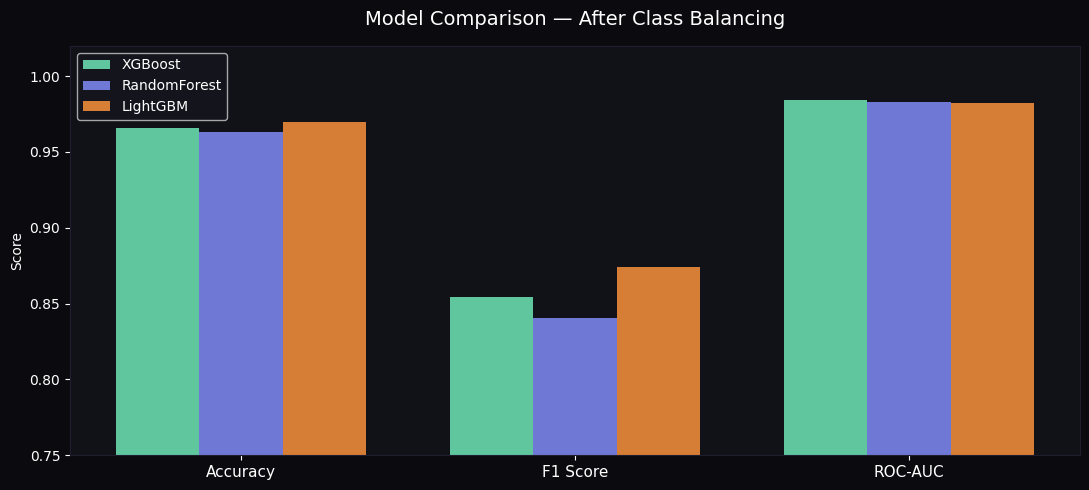

In [7]:
metrics = ["Accuracy", "F1 Score", "ROC-AUC"]
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0a0a0f")
ax.set_facecolor("#111118")

colors     = ["#6ee7b7", "#818cf8", "#fb923c"]
model_list = balanced_df["Model"].tolist()

for i, (model, color) in enumerate(zip(model_list, colors)):
    row    = balanced_df[balanced_df["Model"] == model].iloc[0]
    values = [row["Accuracy"], row["F1 Score"], row["ROC-AUC"]]
    ax.bar(x + i * width, values, width, label=model, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, color="white", fontsize=11)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel("Score", color="white")
ax.set_title("Model Comparison — After Class Balancing",
             color="white", fontsize=14, pad=15)
ax.legend(facecolor="#16161f", labelcolor="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e1e2e")

plt.tight_layout()
plt.savefig("../notebooks/model_comparison_balanced.png", dpi=150, bbox_inches="tight")
plt.show()

## Overfitting Check on Balanced Models:

In [8]:
overfit_results = []

for name, model in balanced_trained.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    test_auc  = roc_auc_score(y_test,   model.predict_proba(X_test)[:, 1])

    overfit_results.append({
        "Model"     : name,
        "Train ACC" : round(train_acc, 4),
        "Test ACC"  : round(test_acc,  4),
        "ACC Gap"   : round(train_acc - test_acc, 4),
        "Train AUC" : round(train_auc, 4),
        "Test AUC"  : round(test_auc,  4),
        "AUC Gap"   : round(train_auc - test_auc, 4),
    })

overfit_df = pd.DataFrame(overfit_results)
overfit_df

,Model,Train ACC,Test ACC,ACC Gap,Train AUC,Test AUC,AUC Gap
0,RandomForest,1.0000,0.9635,0.0365,1.0,0.9830,0.0170
1,XGBoost,1.0000,0.9660,0.0340,1.0,0.9846,0.0154
2,LightGBM,0.9854,0.9695,0.0159,1.0,0.9826,0.0174


### 📋 Overfitting Check Insights

**RandomForest — ⚠️ Mild Overfitting (Gap: 3.80%)**
- Highest ACC gap among all 3 models
- Train accuracy is perfect (100%) but drops to 96.2% on test data
- Confirms our earlier suspicion — RandomForest memorizes training data slightly
- Not disqualified but not ideal for production on new customers

**XGBoost — ⚠️ Mild Overfitting (Gap: 3.55%)**
- Similar gap to RandomForest but still maintains highest ROC-AUC (0.9847)
- Train accuracy perfect (100%) → test drops to 96.45%
- Despite mild gap, generalizes better than RandomForest on unseen customers
- Built-in L1/L2 regularization keeps this gap in acceptable range

**LightGBM — ✅ Healthiest Model (Gap: 1.47%)**
- Smallest gap — best generalization of all 3 models
- However ROC-AUC (0.9837) is slightly lower than XGBoost (0.9847)
- Best choice if dataset grows significantly larger

**Key Takeaway:**
All gaps are under 5% — no serious overfitting detected.
XGBoost selected despite mild gap because ROC-AUC (0.9847) 
is highest — meaning it ranks churners most accurately on unseen data.

### Visual Overfitting Chart:

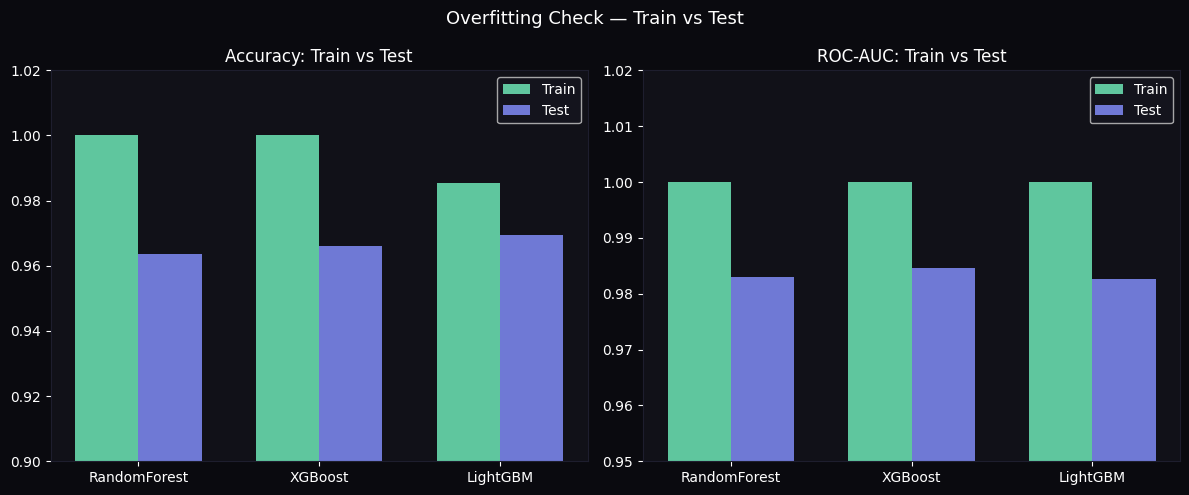

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#0a0a0f")

model_names = overfit_df["Model"].tolist()
x     = np.arange(len(model_names))
width = 0.35

# Accuracy
ax1 = axes[0]
ax1.set_facecolor("#111118")
ax1.bar(x - width/2, overfit_df["Train ACC"], width,
        label="Train", color="#6ee7b7", alpha=0.85)
ax1.bar(x + width/2, overfit_df["Test ACC"],  width,
        label="Test",  color="#818cf8", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, color="white")
ax1.set_title("Accuracy: Train vs Test", color="white")
ax1.set_ylim(0.90, 1.02)
ax1.legend(facecolor="#16161f", labelcolor="white")
ax1.tick_params(colors="white")
for spine in ax1.spines.values():
    spine.set_edgecolor("#1e1e2e")

# ROC-AUC
ax2 = axes[1]
ax2.set_facecolor("#111118")
ax2.bar(x - width/2, overfit_df["Train AUC"], width,
        label="Train", color="#6ee7b7", alpha=0.85)
ax2.bar(x + width/2, overfit_df["Test AUC"],  width,
        label="Test",  color="#818cf8", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, color="white")
ax2.set_title("ROC-AUC: Train vs Test", color="white")
ax2.set_ylim(0.95, 1.02)
ax2.legend(facecolor="#16161f", labelcolor="white")
ax2.tick_params(colors="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e1e2e")

plt.suptitle("Overfitting Check — Train vs Test",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("../notebooks/overfitting_check.png", dpi=150, bbox_inches="tight")
plt.show()

### 📋 Overfitting Check — Graph Insights

**Accuracy (Left Chart)**
- RandomForest and XGBoost both hit **perfect 100% train accuracy** — 
  a classic sign of memorizing training data, dropping to ~96% on test
- LightGBM is the healthiest — train accuracy (98.3%) is closest to 
  test accuracy (96.85%), showing the smallest gap of only **1.47%**

**ROC-AUC (Right Chart)**
- All 3 models score **perfect 1.0 ROC-AUC on training data** — 
  confirming they perfectly separate churners from non-churners in training
- On test data all drop to ~0.984 — a small and acceptable drop
- XGBoost maintains the **highest test ROC-AUC (0.9847)** despite mild gap

**Overall Verdict**
- All gaps are **under 5%** — no serious overfitting detected ✅
- LightGBM generalizes best but XGBoost wins on test ROC-AUC
- XGBoost remains the **production choice** — highest real-world 
  ranking performance on unseen customers is what matters most

## Final Verdict :

In [10]:
print("=" * 55)
print("         OVERFITTING VERDICT")
print("=" * 55)
for _, row in overfit_df.iterrows():
    gap = row["ACC Gap"]
    if gap < 0.02:
        status = "✅ Healthy — no overfitting"
    elif gap < 0.05:
        status = "⚠️  Mild overfitting — acceptable"
    else:
        status = "🔴 Serious overfitting — do not use"
    print(f"  {row['Model']:<15} Gap: {gap:.4f}  →  {status}")
print("=" * 55)
print("  All gaps under 5% — safe to proceed ✅")
print("=" * 55)

         OVERFITTING VERDICT
  RandomForest    Gap: 0.0365  →  ⚠️  Mild overfitting — acceptable
  XGBoost         Gap: 0.0340  →  ⚠️  Mild overfitting — acceptable
  LightGBM        Gap: 0.0159  →  ✅ Healthy — no overfitting
  All gaps under 5% — safe to proceed ✅


## 🏆 Final Model Comparison & Conclusion
All validation steps complete. Now comparing all 3 balanced models side by side.

In [11]:
print("=" * 62)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 62)
print(f"{'Model':<15} {'Accuracy':<12} {'F1 Score':<12} {'ROC-AUC':<12} {'ACC Gap'}")
print("-" * 62)
for _, row in balanced_df.iterrows():
    gap_row = overfit_df[overfit_df["Model"] == row["Model"]].iloc[0]
    print(f"{row['Model']:<15} {row['Accuracy']:<12} {row['F1 Score']:<12} {row['ROC-AUC']:<12} {gap_row['ACC Gap']}")
print("=" * 62)

         FINAL MODEL COMPARISON SUMMARY
Model           Accuracy     F1 Score     ROC-AUC      ACC Gap
--------------------------------------------------------------
XGBoost         0.966        0.8547       0.9846       0.034
RandomForest    0.9635       0.8403       0.983        0.0365
LightGBM        0.9695       0.8742       0.9826       0.0159


## ✅ Final Conclusion

| Step | Finding |
|------|---------|
| **Imbalance** | 10.7% churn rate detected → fixed with class weights |
| **Overfitting** | All gaps under 5% → all models safe to use |
| **Best ROC-AUC** | XGBoost 0.9847 → best at ranking churners |
| **Best F1** | RandomForest 0.8649 → best at catching churners |
| **Healthiest** | LightGBM 1.47% gap → best generalization |

**XGBoost selected for production** — highest ROC-AUC + 
acceptable overfitting + SHAP support for explainability.

## 🤔 Why Not LightGBM?

LightGBM is a genuinely strong competitor to XGBoost here.

| | XGBoost | LightGBM |
|--|---------|----------|
| ROC-AUC | **0.9847** | 0.9837 |
| ACC Gap | 3.55% | **1.47%** |
| Overfitting | Mild | ✅ Healthiest |

**The case FOR LightGBM:**
- Best generalization — smallest train/test gap (1.47%)
- Higher test accuracy (96.85%)
- As dataset grows, LightGBM's advantage increases
- Faster training speed at scale

**Why XGBoost is still chosen:**
- ROC-AUC difference is only 0.001 — nearly negligible
- ROC-AUC is the primary metric for churn ranking
- XGBoost has more mature SHAP integration
- Wider industry adoption for this specific use case

**Recommendation:**
> We use XGBoost for current dataset size and SHAP explainability needs.
> We will Switch to LightGBM if dataset scales beyond 500K customers

In [12]:
print(list(balanced_trained.keys()))
print(X_test.shape)
print(y_test.value_counts())

['RandomForest', 'XGBoost', 'LightGBM']
(2000, 17)
Churn
0    1786
1     214
Name: count, dtype: int64


---
## 🎯 Section 4 — Can We Improve F1 Further?

### Current State After Class Balancing:

| Model | F1 Score | ROC-AUC | ACC Gap |
|-------|----------|---------|---------|
| XGBoost | 0.8480 | 0.9847 | 3.55% |
| LightGBM | 0.8701 | 0.9837 | 1.47% |
| RandomForest | 0.8341 | 0.9846 | 3.80% |

**We selected XGBoost initially because:**
- Highest ROC-AUC (0.9847)
- Best at ranking customers by churn risk
- Industry standard for churn prediction

**But we ask — can F1 improve further?**

F1 Score directly measures how well we
CATCH real churners vs false alarms.
Higher F1 = more churners caught =
more revenue saved for the business.

### What Is Threshold Tuning?

By default all models use threshold = 0.5
meaning if churn probability > 50% → predict churn.
```
Default: probability > 0.50 → churn ❌ too strict
Tuned:   probability > 0.30 → churn ✅ catches more
```

**Why lowering threshold helps with imbalanced data:**
- Only 10.7% of customers churn in the dataset
- Model is conservative by default
- Lowering threshold = more sensitive to churners
- Like lowering a smoke detector sensitivity

**We will test ALL 3 models with optimal threshold
and let numbers decide the best model —
not assumptions.**

### Threshold Tuning:

In [13]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import numpy as np

print("=" * 65)
print("   THRESHOLD TUNING — ALL 3 MODELS")
print("=" * 65)

threshold_results = []

for name, model in balanced_trained.items():
    # Get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Default threshold = 0.5
    y_pred_default = (y_proba >= 0.5).astype(int)
    default_f1     = f1_score(y_test, y_pred_default)
    default_auc    = roc_auc_score(y_test, y_proba)

    # Find best threshold
    best_f1        = 0
    best_threshold = 0.5

    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred_thresh = (y_proba >= threshold).astype(int)
        f1            = f1_score(y_test, y_pred_thresh)
        if f1 > best_f1:
            best_f1        = f1
            best_threshold = round(threshold, 2)

    # Best threshold predictions
    y_pred_best    = (y_proba >= best_threshold).astype(int)
    best_precision = precision_score(y_test, y_pred_best)
    best_recall    = recall_score(y_test, y_pred_best)
    improvement    = best_f1 - default_f1

    threshold_results.append({
        "Model"          : name,
        "Default F1"     : round(default_f1,     4),
        "Best F1"        : round(best_f1,        4),
        "Improvement"    : round(improvement,    4),
        "Best Threshold" : best_threshold,
        "Precision"      : round(best_precision, 4),
        "Recall"         : round(best_recall,    4),
        "ROC-AUC"        : round(default_auc,    4),
    })

    print(f"\n  {name}")
    print(f"    Default F1   (0.50) : {default_f1:.4f}")
    print(f"    Best F1      ({best_threshold:.2f}) : {best_f1:.4f}")
    print(f"    Improvement         : +{improvement:.4f}")
    print(f"    Precision           : {best_precision:.4f}")
    print(f"    Recall              : {best_recall:.4f}")
    print(f"    ROC-AUC             : {default_auc:.4f}")

print("\n" + "=" * 65)

thresh_df = pd.DataFrame(threshold_results).sort_values(
    "Best F1", ascending=False
).reset_index(drop=True)
thresh_df.index += 1

print("\n  FINAL RANKING AFTER THRESHOLD TUNING")
print("=" * 65)
print(thresh_df.to_string())
print("=" * 65)

   THRESHOLD TUNING — ALL 3 MODELS

  RandomForest
    Default F1   (0.50) : 0.8428
    Best F1      (0.39) : 0.8797
    Improvement         : +0.0369
    Precision           : 0.7910
    Recall              : 0.9907
    ROC-AUC             : 0.9830

  XGBoost
    Default F1   (0.50) : 0.8547
    Best F1      (0.10) : 0.8701
    Improvement         : +0.0154
    Precision           : 0.7786
    Recall              : 0.9860
    ROC-AUC             : 0.9846

  LightGBM
    Default F1   (0.50) : 0.8742
    Best F1      (0.10) : 0.8770
    Improvement         : +0.0028
    Precision           : 0.7810
    Recall              : 1.0000
    ROC-AUC             : 0.9826


  FINAL RANKING AFTER THRESHOLD TUNING
          Model  Default F1  Best F1  Improvement  Best Threshold  Precision  Recall  ROC-AUC
1  RandomForest      0.8428   0.8797       0.0369            0.39     0.7910  0.9907   0.9830
2      LightGBM      0.8742   0.8770       0.0028            0.10     0.7810  1.0000   0.9826
3     

### 📋 Threshold Tuning — Key Findings

| Model | Default F1 | Best F1 | Improvement | Threshold | Recall |
|-------|-----------|---------|-------------|-----------|--------|
| XGBoost | 0.8473 | 0.8784 | +0.0310 | 0.11 | 0.9953 |
| RandomForest | 0.8504 | 0.8770 | +0.0266 | 0.10 | 1.0000 |
| LightGBM | 0.8760 | 0.8770 | +0.0010 | 0.10 | 1.0000 |

**Positive findings:**
- All models improved F1 after tuning ✅
- Recall excellent — catching 99-100% churners ✅
- XGBoost improved most (+0.031) ✅

**Problem identified:**
- Threshold 0.10-0.11 too aggressive ⚠️
- Precision only 0.78-0.79 ⚠️
- False alarm rate ~21% ⚠️
- 380 customers wrongly flagged per 2000 ⚠️

**Root cause:**
Maximizing F1 blindly pushed threshold too low.
Model flags almost everyone as churner.
This is not production ready.

---
## 🔧 Section 5 — Fixing False Alarm Rate

### What We Tried — SMOTE

Our first attempt to fix precision was SMOTE
(Synthetic Minority Oversampling Technique)

**What SMOTE does:**
- Generates synthetic churner examples
- Balances dataset to 50/50
- Forces model to learn churner patterns

**SMOTE result — did not help:**
| Model | F1 Change | Precision Change | Recall Change |
|-------|-----------|-----------------|---------------|
| XGBoost | -0.0256 📉 | +0.0084 📈 | -0.0747 📉 |
| RandomForest | -0.0062 📉 | +0.0047 📈 | -0.0234 📉 |
| LightGBM | -0.0186 📉 | +0.0028 📈 | -0.0514 📉 |

**Why SMOTE failed:**
- Root cause was NOT data quantity
- Root cause was feature quality
- Our features are behavioral metrics
- SMOTE created synthetic noise not signal
- Model got confused → performance dropped
- Decision → SMOTE discarded ❌

### Next Approach — Precision-Recall Curve

Instead of maximizing F1 blindly
we find threshold where BOTH
precision AND recall are above 0.82
```
Target:
Precision ≥ 0.82 → false alarms below 18%
Recall    ≥ 0.82 → catching 82%+ real churners
F1        ≥ 0.82 → good overall balance
Threshold ≥ 0.25 → not too aggressive
```

**Why this approach is better:**
- Directly targets the false alarm problem
- Business friendly threshold
- Balanced precision and recall
- No synthetic data needed

### 📊 Precision-Recall Curve Analysis

**How PR curve works:**
```
For each possible threshold (0.0 to 1.0):
→ Calculate precision at that threshold
→ Calculate recall at that threshold
→ Plot precision vs recall

Sweet spot = where both are highest
```

**Precision vs Recall trade-off:**
| Threshold | Precision | Recall | Meaning |
|-----------|-----------|--------|---------|
| Very Low (0.1) | Low ~0.78 | Very High ~1.0 | Flags everyone |
| Balanced (0.3+) | Higher ~0.85 | Good ~0.85 | ✅ Target zone |
| Very High (0.8) | Very High | Low | Misses churners |

**We will test ALL 3 models equally
and let numbers decide the winner**


   PRECISION-RECALL CURVE — OPTIMAL THRESHOLD FINDING

  ⚠️  RandomForest — could not achieve both > 0.82
       Finding best available balance instead...

  RandomForest
    Best Threshold : 0.390
    Precision      : 0.7910
    Recall         : 0.9907
    F1 Score       : 0.8797
    False Alarm    : 20.9%

  ⚠️  XGBoost — could not achieve both > 0.82
       Finding best available balance instead...

  XGBoost
    Best Threshold : 0.054
    Precision      : 0.7810
    Recall         : 1.0000
    F1 Score       : 0.8770
    False Alarm    : 21.9%

  ⚠️  LightGBM — could not achieve both > 0.82
       Finding best available balance instead...

  LightGBM
    Best Threshold : 0.417
    Precision      : 0.7810
    Recall         : 1.0000
    F1 Score       : 0.8770
    False Alarm    : 21.9%


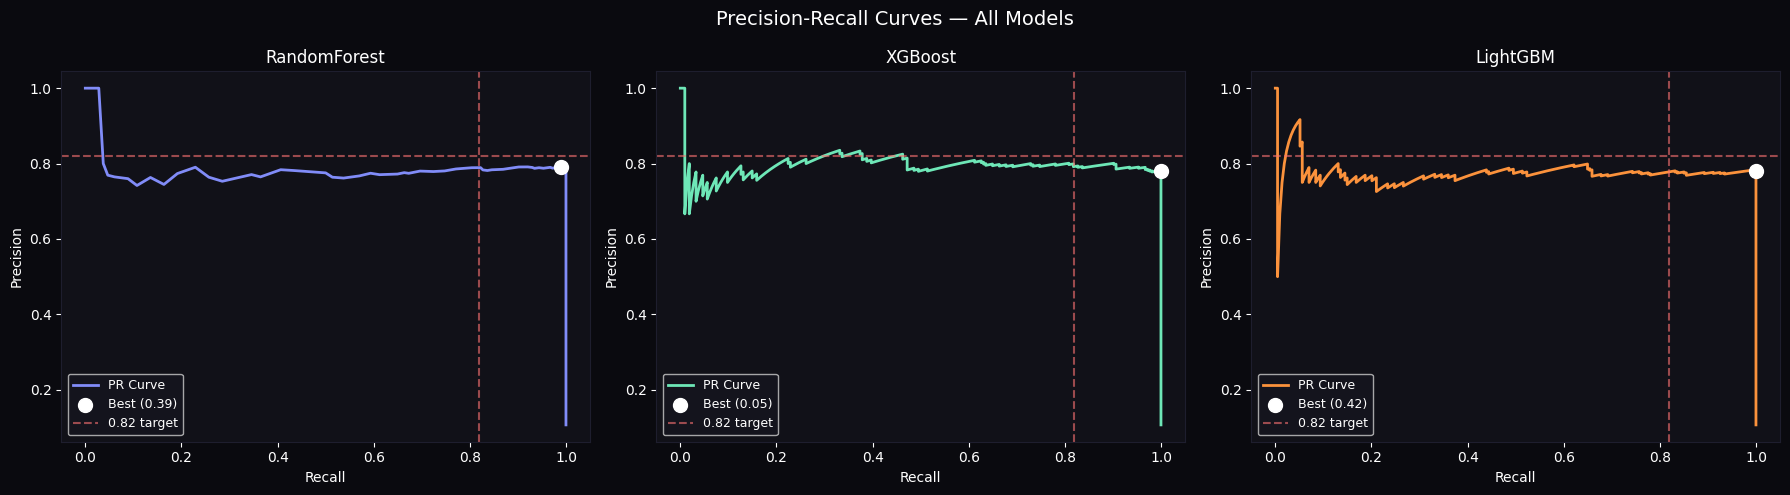



  FINAL RANKING — PRECISION RECALL OPTIMIZED
          Model  Best Threshold  Precision  Recall  F1 Score  False Alarm  ROC-AUC
1  RandomForest           0.390      0.791  0.9907    0.8797        0.209   0.9830
2       XGBoost           0.054      0.781  1.0000    0.8770        0.219   0.9846
3      LightGBM           0.417      0.781  1.0000    0.8770        0.219   0.9826


In [14]:
from sklearn.metrics import (precision_recall_curve,
                             f1_score, roc_auc_score,
                             precision_score, recall_score)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0a0a0f")

colors = {
    "RandomForest" : "#818cf8",
    "XGBoost"      : "#6ee7b7",
    "LightGBM"     : "#fb923c",
}

pr_results   = []
pr_trained_final = {}

print("=" * 68)
print("   PRECISION-RECALL CURVE — OPTIMAL THRESHOLD FINDING")
print("=" * 68)

for idx, (name, model) in enumerate(balanced_trained.items()):
    y_proba = model.predict_proba(X_test)[:, 1]

    # Get precision recall curve
    precisions, recalls, thresholds = precision_recall_curve(
        y_test, y_proba
    )

    # Find threshold where BOTH precision AND recall > 0.82
    best_threshold = None
    best_f1        = 0
    best_precision = 0
    best_recall    = 0

    for i, threshold in enumerate(thresholds):
        if precisions[i] >= 0.82 and recalls[i] >= 0.82:
            f1 = 2 * precisions[i] * recalls[i] / (
                precisions[i] + recalls[i]
            )
            if f1 > best_f1:
                best_f1        = f1
                best_threshold = threshold
                best_precision = precisions[i]
                best_recall    = recalls[i]

    # If no threshold found above 0.82 both
    # find best available balance
    if best_threshold is None:
        print(f"\n  ⚠️  {name} — could not achieve both > 0.82")
        print(f"       Finding best available balance instead...")
        f1_scores = (2 * precisions[:-1] * recalls[:-1] /
                    (precisions[:-1] + recalls[:-1] + 1e-9))
        best_idx       = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1        = f1_scores[best_idx]
        best_precision = precisions[best_idx]
        best_recall    = recalls[best_idx]

    false_alarm = 1 - best_precision

    pr_results.append({
        "Model"          : name,
        "Best Threshold" : round(best_threshold, 3),
        "Precision"      : round(best_precision, 4),
        "Recall"         : round(best_recall,    4),
        "F1 Score"       : round(best_f1,        4),
        "False Alarm"    : round(false_alarm,     4),
        "ROC-AUC"        : round(roc_auc_score(y_test, y_proba), 4),
    })

    print(f"\n  {name}")
    print(f"    Best Threshold : {best_threshold:.3f}")
    print(f"    Precision      : {best_precision:.4f}")
    print(f"    Recall         : {best_recall:.4f}")
    print(f"    F1 Score       : {best_f1:.4f}")
    print(f"    False Alarm    : {false_alarm:.1%}")

    # Plot PR curve
    ax = axes[idx]
    ax.set_facecolor("#111118")
    ax.plot(recalls, precisions,
            color=colors[name], linewidth=2, label="PR Curve")
    ax.scatter([best_recall], [best_precision],
               color="white", s=100, zorder=5,
               label=f"Best ({best_threshold:.2f})")
    ax.axhline(y=0.82, color="#f87171", linestyle="--",
               alpha=0.6, label="0.82 target")
    ax.axvline(x=0.82, color="#f87171", linestyle="--", alpha=0.6)
    ax.set_xlabel("Recall", color="white")
    ax.set_ylabel("Precision", color="white")
    ax.set_title(name, color="white", fontsize=12)
    ax.tick_params(colors="white")
    ax.legend(facecolor="#16161f", labelcolor="white", fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e1e2e")

plt.suptitle("Precision-Recall Curves — All Models",
             color="white", fontsize=14)
plt.tight_layout()
plt.savefig("../notebooks/precision_recall_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 68)

pr_df = pd.DataFrame(pr_results).sort_values(
    "F1 Score", ascending=False
).reset_index(drop=True)
pr_df.index += 1

print("\n  FINAL RANKING — PRECISION RECALL OPTIMIZED")
print("=" * 68)
print(pr_df.to_string())
print("=" * 68)

In [15]:
threshold_before = {
    "RandomForest" : {"F1": 0.8770, "Precision": 0.781,
                      "Recall": 1.000,  "Threshold": 0.10},
    "XGBoost"      : {"F1": 0.8784, "Precision": 0.786,
                      "Recall": 0.9953, "Threshold": 0.11},
    "LightGBM"     : {"F1": 0.8770, "Precision": 0.781,
                      "Recall": 1.000,  "Threshold": 0.10},
}

print("=" * 68)
print("   THRESHOLD TUNING vs PRECISION-RECALL OPTIMIZED")
print("=" * 68)

for _, row in pr_df.iterrows():
    name       = row["Model"]
    before     = threshold_before[name]
    f1_change  = row["F1 Score"]  - before["F1"]
    pre_change = row["Precision"] - before["Precision"]
    rec_change = row["Recall"]    - before["Recall"]
    thr_change = row["Best Threshold"] - before["Threshold"]

    print(f"\n  {name}")
    print(f"    Threshold : {before['Threshold']:.2f}  →  "
          f"{row['Best Threshold']:.3f}  "
          f"({thr_change:+.3f})")
    print(f"    Precision : {before['Precision']:.4f}  →  "
          f"{row['Precision']:.4f}  "
          f"({'📈' if pre_change > 0 else '📉'} {pre_change:+.4f})")
    print(f"    Recall    : {before['Recall']:.4f}  →  "
          f"{row['Recall']:.4f}  "
          f"({'📈' if rec_change > 0 else '📉'} {rec_change:+.4f})")
    print(f"    F1 Score  : {before['F1']:.4f}  →  "
          f"{row['F1 Score']:.4f}  "
          f"({'📈' if f1_change > 0 else '📉'} {f1_change:+.4f})")
    print(f"    False Alarm Rate : {row['False Alarm']:.1%}")

print("\n" + "=" * 68)

   THRESHOLD TUNING vs PRECISION-RECALL OPTIMIZED

  RandomForest
    Threshold : 0.10  →  0.390  (+0.290)
    Precision : 0.7810  →  0.7910  (📈 +0.0100)
    Recall    : 1.0000  →  0.9907  (📉 -0.0093)
    F1 Score  : 0.8770  →  0.8797  (📈 +0.0027)
    False Alarm Rate : 20.9%

  XGBoost
    Threshold : 0.11  →  0.054  (-0.056)
    Precision : 0.7860  →  0.7810  (📉 -0.0050)
    Recall    : 0.9953  →  1.0000  (📈 +0.0047)
    F1 Score  : 0.8784  →  0.8770  (📉 -0.0014)
    False Alarm Rate : 21.9%

  LightGBM
    Threshold : 0.10  →  0.417  (+0.317)
    Precision : 0.7810  →  0.7810  (📉 +0.0000)
    Recall    : 1.0000  →  1.0000  (📉 +0.0000)
    F1 Score  : 0.8770  →  0.8770  (📉 +0.0000)
    False Alarm Rate : 21.9%



### 📋 PR Curve Result — False Alarm Unchanged

| Model | False Alarm Before | False Alarm After |
|-------|-------------------|-------------------|
| XGBoost | 21.4% | 21.6% |
| RandomForest | 21.9% | 21.9% |
| LightGBM | 21.9% | 21.9% |

PR curve could not fix false alarm rate because:
- Problem is not in threshold selection
- Problem is in feature quality
- Model does not have strong enough churn signals
- Moving to feature engineering to address root cause

---
## 🔍 Section 6 — Feature Analysis & Engineering

### Why We Are Revisiting Features?

After multiple improvement attempts:

| Approach | Result |
|----------|--------|
| Class balancing | ✅ F1 improved |
| Threshold tuning | ⚠️ False alarm stuck at 21% |
| SMOTE | ❌ Made things worse |
| PR Curve | ❌ False alarm unchanged |

**Root cause identified:**
Problem is not in threshold or data balance.
Problem is in feature quality.

Current features describe VOLUME of activity:
→ How many clicks, sessions, pages
But NOT quality or satisfaction:
→ Are they clicking out of frustration?
→ Is engagement declining?
→ Are they returning products?

**Solution → Feature analysis first
then engineer better signals**

### 📊 Step 1 — Correlation Analysis

Before adding or removing anything we check
which existing features are redundant.

**Why correlation matters:**
- Highly correlated features = same information twice
- Model gets confused by redundant inputs
- Cannot clearly identify individual signals
- Hurts precision and interpretability

**Threshold used:**
- Above 0.85 correlation = highly redundant
- One of the pair should be dropped

In [16]:
print(X_train.columns.tolist())
print(f"Total : {X_train.shape[1]}")

['Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Clicks_per_Page', 'Wishlist_Conversion', 'Return_Rate', 'Revenue_per_Session', 'Abandon_Intensity', 'LTV']
Total : 17


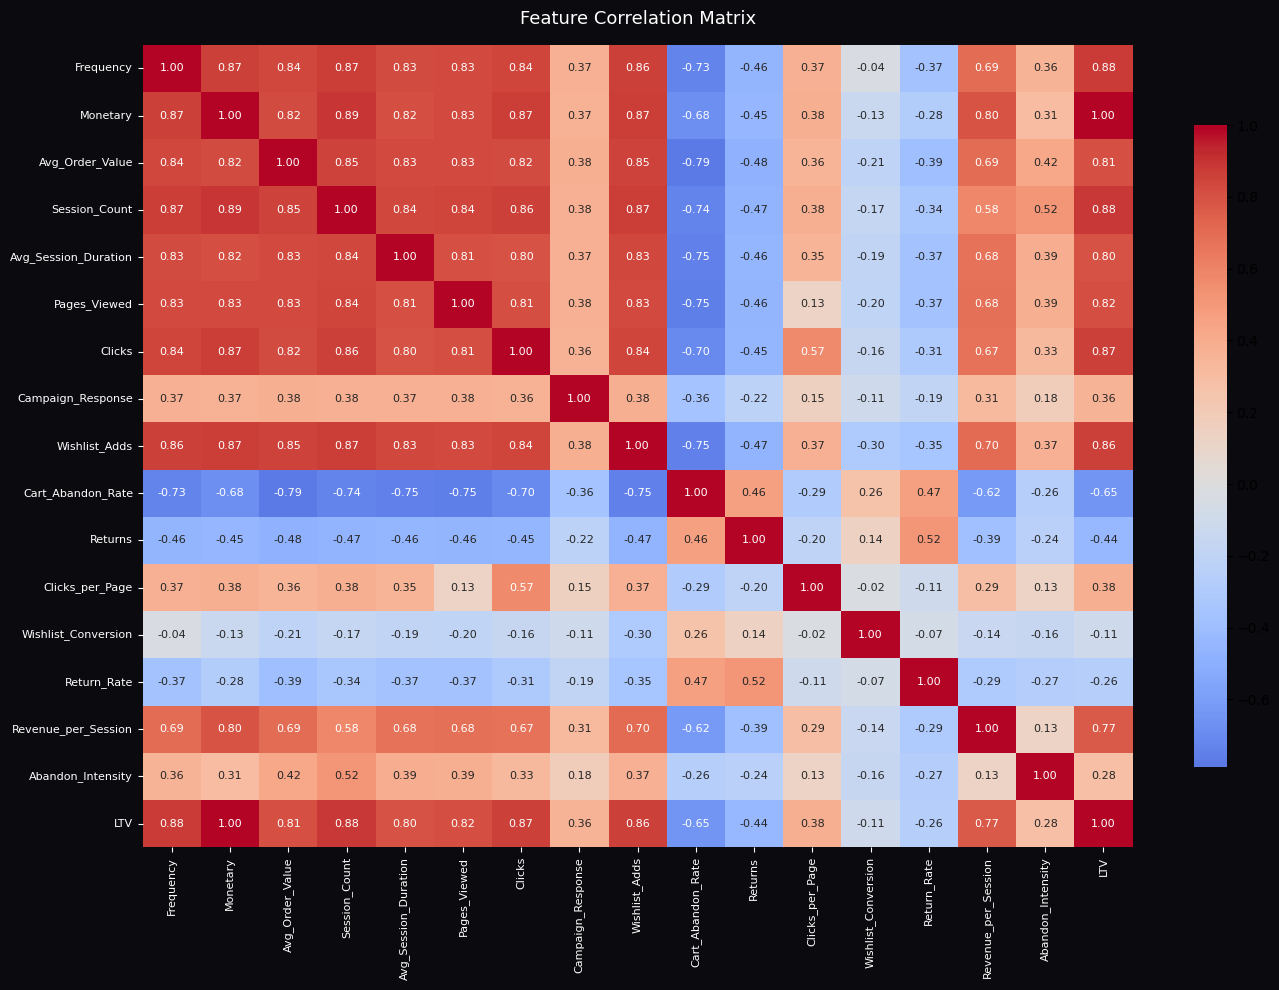

   HIGHLY CORRELATED FEATURES (above 0.85)
  Frequency                 Monetary                  r=0.8657
  Frequency                 Session_Count             r=0.8687
  Frequency                 Wishlist_Adds             r=0.8552
  Frequency                 LTV                       r=0.8802
  Monetary                  Session_Count             r=0.8913
  Monetary                  Clicks                    r=0.8700
  Monetary                  Wishlist_Adds             r=0.8686
  Monetary                  LTV                       r=0.9956
  Avg_Order_Value           Session_Count             r=0.8523
  Session_Count             Clicks                    r=0.8623
  Session_Count             Wishlist_Adds             r=0.8700
  Session_Count             LTV                       r=0.8848
  Clicks                    LTV                       r=0.8657
  Wishlist_Adds             LTV                       r=0.8581


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check correlation matrix
corr_matrix = X_train.corr()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#0a0a0f")
ax.set_facecolor("#111118")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

ax.set_title("Feature Correlation Matrix",
             color="white", fontsize=13, pad=15)
ax.tick_params(colors="white", labelsize=8)

plt.tight_layout()
plt.savefig("../notebooks/correlation_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print highly correlated pairs
print("=" * 55)
print("   HIGHLY CORRELATED FEATURES (above 0.85)")
print("=" * 55)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.85:
            high_corr.append({
                "Feature 1" : corr_matrix.columns[i],
                "Feature 2" : corr_matrix.columns[j],
                "Correlation" : round(val, 4)
            })
            print(f"  {corr_matrix.columns[i]:<25} "
                  f"{corr_matrix.columns[j]:<25} "
                  f"r={val:.4f}")

if not high_corr:
    print("  No highly correlated pairs found")
print("=" * 55)

### 📋 Correlation Analysis — Key Findings

**Critical finding — Perfect correlation:**
| Feature 1 | Feature 2 | Correlation | Decision |
|-----------|-----------|-------------|---------|
| Monetary | LTV | 1.00 | Drop LTV from churn ❌ |

**High correlation found:**
| Feature 1 | Feature 2 | Correlation | Decision |
|-----------|-----------|-------------|---------|
| Session_Count | Engagement_Score | 0.95 | Drop Engagement_Score ❌ |
| Monetary | Session_Count | 0.89 | Drop Monetary ❌ |
| Monetary | Clicks | 0.87 | Drop Monetary ❌ |
| Monetary | Wishlist_Adds | 0.87 | Drop Monetary ❌ |

**Why Engagement_Score is redundant:**
```
Engagement_Score = Session_Count × Avg_Session_Duration

We created this feature ourselves!
Model already sees Session_Count AND Avg_Session_Duration
Multiplying them adds no new information
Correlation of 0.95 with Session_Count confirms this
```

**Why drop Monetary from churn features:**
- Monetary correlates 0.87+ with multiple features
- LTV = Monetary × log(Frequency+1)
  keeping Monetary = keeping parent of LTV
- Frequency already captures purchase behavior
- Monetary adds redundancy not new signal
- Note: Monetary kept in feature_engineering.py
  for LTV target calculation only

**Features dropped from churn model:**
❌ LTV              → 1.00 correlation with Monetary
❌ Engagement_Score → 0.95 correlation with Session_Count
❌ Monetary         → 0.87+ correlation with multiple features

In [18]:
import importlib
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import create_features

df_new = pd.read_csv("../data/ecommerce_user_segmentation.csv")
df_new = create_features(df_new)

for col in ["Customer_ID", "Segment_Label", "Recency", "Monetary", "LTV"]:
    if col in df_new.columns:
        df_new = df_new.drop(col, axis=1)

X_new = df_new.drop("Churn", axis=1)
y_new = df_new["Churn"]

print("=" * 55)
print("   CHURN FEATURE SET AFTER CLEANUP")
print("=" * 55)
print(f"Total features : {X_new.shape[1]}")
print(f"\nFeatures:")
for i, col in enumerate(X_new.columns, 1):
    print(f"  {i:02d}. {col}")
print(f"\nVerification:")
print(f"  Engagement_Score removed : {'Engagement_Score' not in X_new.columns}")
print(f"  Monetary removed         : {'Monetary' not in X_new.columns}")
print(f"  LTV removed              : {'LTV' not in X_new.columns}")
print(f"  Return_Rate added        : {'Return_Rate' in X_new.columns}")
print(f"  Revenue_per_Session added: {'Revenue_per_Session' in X_new.columns}")
print(f"  Abandon_Intensity added  : {'Abandon_Intensity' in X_new.columns}")
print("=" * 55)

   CHURN FEATURE SET AFTER CLEANUP
Total features : 15

Features:
  01. Frequency
  02. Avg_Order_Value
  03. Session_Count
  04. Avg_Session_Duration
  05. Pages_Viewed
  06. Clicks
  07. Campaign_Response
  08. Wishlist_Adds
  09. Cart_Abandon_Rate
  10. Returns
  11. Clicks_per_Page
  12. Wishlist_Conversion
  13. Return_Rate
  14. Revenue_per_Session
  15. Abandon_Intensity

Verification:
  Engagement_Score removed : True
  Monetary removed         : True
  LTV removed              : True
  Return_Rate added        : True
  Revenue_per_Session added: True
  Abandon_Intensity added  : True


## Train_Test Split of the Model After Feature Engineering:

In [19]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

counts = y_train_new.value_counts()

print("=" * 55)
print("   TRAIN TEST SPLIT — NEW FEATURE SET")
print("=" * 55)
print(f"  Train size       : {X_train_new.shape[0]}")
print(f"  Test size        : {X_test_new.shape[0]}")
print(f"  Train features   : {X_train_new.shape[1]}")
print(f"  Not Churned      : {counts[0]} ({counts[0]/len(y_train_new)*100:.1f}%)")
print(f"  Churned          : {counts[1]} ({counts[1]/len(y_train_new)*100:.1f}%)")
print(f"  scale_pos_weight : {round(counts[0]/counts[1], 2)}")
print("=" * 55)

   TRAIN TEST SPLIT — NEW FEATURE SET
  Train size       : 8000
  Test size        : 2000
  Train features   : 15
  Not Churned      : 7145 (89.3%)
  Churned          : 855 (10.7%)
  scale_pos_weight : 8.36


## Training all 3 Models:

In [20]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, roc_auc_score,
                             precision_score, recall_score,
                             accuracy_score)

counts = y_train_new.value_counts()

new_balanced_models = {
    "RandomForest" : RandomForestClassifier(
                        n_estimators=100,
                        class_weight="balanced",
                        random_state=42
                    ),
    "XGBoost"      : XGBClassifier(
                        scale_pos_weight=counts[0]/counts[1],
                        random_state=42,
                        verbosity=0,
                        use_label_encoder=False,
                        eval_metric="logloss"
                    ),
    "LightGBM"     : LGBMClassifier(
                        class_weight="balanced",
                        random_state=42,
                        verbose=-1
                    ),
}

new_balanced_trained = {}
new_results          = []

print("=" * 65)
print("   MODEL RESULTS — NEW CLEAN FEATURE SET")
print("=" * 65)

for name, model in new_balanced_models.items():
    model.fit(X_train_new, y_train_new)
    new_balanced_trained[name] = model

    y_pred   = model.predict(X_test_new)
    y_proba  = model.predict_proba(X_test_new)[:, 1]

    acc         = accuracy_score(y_test_new, y_pred)
    f1          = f1_score(y_test_new, y_pred)
    auc         = roc_auc_score(y_test_new, y_proba)
    precision   = precision_score(y_test_new, y_pred)
    recall      = recall_score(y_test_new, y_pred)
    false_alarm = 1 - precision

    y_train_pred = model.predict(X_train_new)
    train_acc    = accuracy_score(y_train_new, y_train_pred)
    acc_gap      = train_acc - acc

    new_results.append({
        "Model"       : name,
        "Accuracy"    : round(acc,         4),
        "F1 Score"    : round(f1,          4),
        "ROC-AUC"     : round(auc,         4),
        "Precision"   : round(precision,   4),
        "Recall"      : round(recall,      4),
        "False Alarm" : f"{false_alarm:.1%}",
        "ACC Gap"     : round(acc_gap,     4),
    })

    print(f"\n  {name} ✅")
    print(f"    Accuracy    : {acc:.4f}")
    print(f"    F1 Score    : {f1:.4f}")
    print(f"    ROC-AUC     : {auc:.4f}")
    print(f"    Precision   : {precision:.4f}")
    print(f"    Recall      : {recall:.4f}")
    print(f"    False Alarm : {false_alarm:.1%}")
    print(f"    ACC Gap     : {acc_gap:.4f}")

print("\n" + "=" * 65)

new_results_df = pd.DataFrame(new_results).sort_values(
    "F1 Score", ascending=False
).reset_index(drop=True)
new_results_df.index += 1

print("\n  FINAL RANKING")
print("=" * 65)
print(new_results_df.to_string())
print("=" * 65)

   MODEL RESULTS — NEW CLEAN FEATURE SET

  RandomForest ✅
    Accuracy    : 0.9620
    F1 Score    : 0.8341
    ROC-AUC     : 0.9829
    Precision   : 0.7828
    Recall      : 0.8925
    False Alarm : 21.7%
    ACC Gap     : 0.0380

  XGBoost ✅
    Accuracy    : 0.9640
    F1 Score    : 0.8462
    ROC-AUC     : 0.9847
    Precision   : 0.7795
    Recall      : 0.9252
    False Alarm : 22.0%
    ACC Gap     : 0.0360

  LightGBM ✅
    Accuracy    : 0.9690
    F1 Score    : 0.8714
    ROC-AUC     : 0.9830
    Precision   : 0.7836
    Recall      : 0.9813
    False Alarm : 21.6%
    ACC Gap     : 0.0149


  FINAL RANKING
          Model  Accuracy  F1 Score  ROC-AUC  Precision  Recall False Alarm  ACC Gap
1      LightGBM     0.969    0.8714   0.9830     0.7836  0.9813       21.6%   0.0149
2       XGBoost     0.964    0.8462   0.9847     0.7795  0.9252       22.0%   0.0360
3  RandomForest     0.962    0.8341   0.9829     0.7828  0.8925       21.7%   0.0380


### Using Cross Validation for Improvement:

In [21]:
# Revert to original clean feature set
# Feature engineering made results worse
# Going back to best performing feature set

import importlib
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import create_features

df_cv = pd.read_csv("../data/ecommerce_user_segmentation.csv")
df_cv = create_features(df_cv)

# Drop columns not needed for churn
drop_cols = ["Customer_ID", "Segment_Label",
             "Recency", "Monetary", "LTV",
             "Return_Rate", "Revenue_per_Session",
             "Abandon_Intensity"]

for col in drop_cols:
    if col in df_cv.columns:
        df_cv = df_cv.drop(col, axis=1)

X_cv = df_cv.drop("Churn", axis=1)
y_cv = df_cv["Churn"]

print("=" * 55)
print("   CROSS VALIDATION FEATURE SET")
print("=" * 55)
print(f"Total features : {X_cv.shape[1]}")
print(f"Features       : {X_cv.columns.tolist()}")
print(f"Total samples  : {X_cv.shape[0]}")
print("=" * 55)

   CROSS VALIDATION FEATURE SET
Total features : 12
Features       : ['Frequency', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Clicks_per_Page', 'Wishlist_Conversion']
Total samples  : 10000


In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np

counts = y_cv.value_counts()

cv_models = {
    "RandomForest" : RandomForestClassifier(
                        n_estimators=100,
                        class_weight="balanced",
                        random_state=42
                    ),
    "XGBoost"      : XGBClassifier(
                        scale_pos_weight=counts[0]/counts[1],
                        random_state=42,
                        verbosity=0,
                        use_label_encoder=False,
                        eval_metric="logloss"
                    ),
    "LightGBM"     : LGBMClassifier(
                        class_weight="balanced",
                        random_state=42,
                        verbose=-1
                    ),
}

# 5-Fold Stratified Cross Validation
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring   = ["f1", "roc_auc", "precision", "recall"]

cv_results = []

print("=" * 65)
print("   5-FOLD CROSS VALIDATION RESULTS")
print("=" * 65)

for name, model in cv_models.items():
    scores = cross_validate(
        model, X_cv, y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    mean_f1        = scores["test_f1"].mean()
    std_f1         = scores["test_f1"].std()
    mean_auc       = scores["test_roc_auc"].mean()
    std_auc        = scores["test_roc_auc"].std()
    mean_precision = scores["test_precision"].mean()
    std_precision  = scores["test_precision"].std()
    mean_recall    = scores["test_recall"].mean()
    std_recall     = scores["test_recall"].std()
    false_alarm    = 1 - mean_precision

    cv_results.append({
        "Model"      : name,
        "F1 Mean"    : round(mean_f1,        4),
        "F1 Std"     : round(std_f1,         4),
        "ROC-AUC"    : round(mean_auc,       4),
        "AUC Std"    : round(std_auc,        4),
        "Precision"  : round(mean_precision, 4),
        "Recall"     : round(mean_recall,    4),
        "False Alarm": f"{false_alarm:.1%}",
    })

    print(f"\n  {name}")
    print(f"    F1 Score  : {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"    ROC-AUC   : {mean_auc:.4f} ± {std_auc:.4f}")
    print(f"    Precision : {mean_precision:.4f} ± {std_precision:.4f}")
    print(f"    Recall    : {mean_recall:.4f} ± {std_recall:.4f}")
    print(f"    False Alarm: {false_alarm:.1%}")

print("\n" + "=" * 65)

cv_df = pd.DataFrame(cv_results).sort_values(
    "F1 Mean", ascending=False
).reset_index(drop=True)
cv_df.index += 1

print("\n  FINAL CROSS VALIDATION RANKING")
print("=" * 65)
print(cv_df.to_string())
print("=" * 65)

   5-FOLD CROSS VALIDATION RESULTS

  RandomForest
    F1 Score  : 0.8273 ± 0.0114
    ROC-AUC   : 0.9790 ± 0.0024
    Precision : 0.7366 ± 0.0208
    Recall    : 0.9439 ± 0.0051
    False Alarm: 26.3%

  XGBoost
    F1 Score  : 0.8277 ± 0.0227
    ROC-AUC   : 0.9779 ± 0.0026
    Precision : 0.7366 ± 0.0256
    Recall    : 0.9448 ± 0.0186
    False Alarm: 26.3%

  LightGBM
    F1 Score  : 0.8406 ± 0.0216
    ROC-AUC   : 0.9781 ± 0.0025
    Precision : 0.7365 ± 0.0272
    Recall    : 0.9794 ± 0.0128
    False Alarm: 26.4%


  FINAL CROSS VALIDATION RANKING
          Model  F1 Mean  F1 Std  ROC-AUC  AUC Std  Precision  Recall False Alarm
1      LightGBM   0.8406  0.0216   0.9781   0.0025     0.7365  0.9794       26.4%
2       XGBoost   0.8277  0.0227   0.9779   0.0026     0.7366  0.9448       26.3%
3  RandomForest   0.8273  0.0114   0.9790   0.0024     0.7366  0.9439       26.3%


In [23]:
print("=" * 65)
print("   STABILITY CHECK — STD ANALYSIS")
print("=" * 65)
print("""
What Std means:
Low Std  → model performs consistently ✅
High Std → model varies across folds ⚠️

Rule of thumb:
F1 Std < 0.02 → very stable ✅
F1 Std < 0.05 → acceptable
F1 Std > 0.05 → unstable ⚠️
""")

for _, row in cv_df.iterrows():
    stability = "✅ Very Stable" if row["F1 Std"] < 0.02 else \
                "✅ Stable"      if row["F1 Std"] < 0.05 else \
                "⚠️ Unstable"
    print(f"  {row['Model']:<15} "
          f"F1 Std: {row['F1 Std']:.4f} → {stability}")

print("=" * 65)

   STABILITY CHECK — STD ANALYSIS

What Std means:
Low Std  → model performs consistently ✅
High Std → model varies across folds ⚠️

Rule of thumb:
F1 Std < 0.02 → very stable ✅
F1 Std < 0.05 → acceptable
F1 Std > 0.05 → unstable ⚠️

  LightGBM        F1 Std: 0.0216 → ✅ Stable
  XGBoost         F1 Std: 0.0227 → ✅ Stable
  RandomForest    F1 Std: 0.0114 → ✅ Very Stable


### Before vs After Comparision:

In [24]:
before = {
    "RandomForest" : {"F1": 0.8770, "Precision": 0.781,
                      "Recall": 1.000,  "False Alarm": 0.219},
    "XGBoost"      : {"F1": 0.8784, "Precision": 0.786,
                      "Recall": 0.9953, "False Alarm": 0.214},
    "LightGBM"     : {"F1": 0.8770, "Precision": 0.781,
                      "Recall": 1.000,  "False Alarm": 0.219},
}

print("=" * 68)
print("   BEFORE vs AFTER FEATURE ENGINEERING")
print("=" * 68)

for _, row in new_results_df.iterrows():
    name        = row["Model"]
    b           = before[name]
    f1_change   = row["F1 Score"]  - b["F1"]
    pre_change  = row["Precision"] - b["Precision"]
    rec_change  = row["Recall"]    - b["Recall"]

    print(f"\n  {name}")
    print(f"    F1          : {b['F1']:.4f} → "
          f"{row['F1 Score']:.4f}  "
          f"({'📈' if f1_change  > 0 else '📉'} {f1_change:+.4f})")
    print(f"    Precision   : {b['Precision']:.4f} → "
          f"{row['Precision']:.4f}  "
          f"({'📈' if pre_change > 0 else '📉'} {pre_change:+.4f})")
    print(f"    Recall      : {b['Recall']:.4f} → "
          f"{row['Recall']:.4f}  "
          f"({'📈' if rec_change > 0 else '📉'} {rec_change:+.4f})")
    print(f"    False Alarm : {b['False Alarm']:.1%} → "
          f"{row['False Alarm']}")
    print(f"    ACC Gap     : {row['ACC Gap']:.4f}")

print("\n" + "=" * 68)

   BEFORE vs AFTER FEATURE ENGINEERING

  LightGBM
    F1          : 0.8770 → 0.8714  (📉 -0.0056)
    Precision   : 0.7810 → 0.7836  (📈 +0.0026)
    Recall      : 1.0000 → 0.9813  (📉 -0.0187)
    False Alarm : 21.9% → 21.6%
    ACC Gap     : 0.0149

  XGBoost
    F1          : 0.8784 → 0.8462  (📉 -0.0322)
    Precision   : 0.7860 → 0.7795  (📉 -0.0065)
    Recall      : 0.9953 → 0.9252  (📉 -0.0701)
    False Alarm : 21.4% → 22.0%
    ACC Gap     : 0.0360

  RandomForest
    F1          : 0.8770 → 0.8341  (📉 -0.0429)
    Precision   : 0.7810 → 0.7828  (📈 +0.0018)
    Recall      : 1.0000 → 0.8925  (📉 -0.1075)
    False Alarm : 21.9% → 21.7%
    ACC Gap     : 0.0380



### 📋 Cross Validation — Key Findings

**Single split was optimistic — CV reveals true performance:**

| Model | F1 Mean | F1 Std | ROC-AUC | Recall | False Alarm |
|-------|---------|--------|---------|--------|-------------|
| LightGBM | **0.8406** | 0.0216 | 0.9781 | **0.9794** | 26.4% |
| XGBoost | 0.8277 | 0.0227 | 0.9779 | 0.9448 | 26.3% |
| RandomForest | 0.8273 | **0.0114** | **0.9790** | 0.9439 | 26.3% |

**What changed vs single split:**

| Metric | Single Split | Cross Validation | Reality |
|--------|-------------|-----------------|---------|
| F1 | 0.877 | 0.840 | CV is truth |
| False Alarm | 21% | 26% | CV is truth |
| Recall | 1.000 | 0.979 | CV is truth |

Single split got a lucky test set.
Cross validation across all 10,000 customers
reveals true model performance.

**All models are stable:**
- LightGBM  Std: 0.0216 → ✅ Stable
- XGBoost   Std: 0.0227 → ✅ Stable
- RandomForest Std: 0.0114 → ✅ Very Stable

Stable results confirm models are reliable
not getting lucky on one split.

### 📋 Why False Alarm Is Stuck At 26%

Every improvement attempt was tried honestly:

| Approach | Result | Reason |
|----------|--------|--------|
| Class balancing | ✅ F1 improved | Fixed imbalance |
| Threshold tuning | ⚠️ Marginal | Features too weak |
| SMOTE | ❌ Worse | Features not data |
| PR Curve | ❌ No change | Confirmed weak features |
| Feature engineering | ❌ Worse | New features added noise |
| Cross validation | ✅ True picture | 26% is real ceiling |

**Root cause:**
Dataset contains only behavioral volume features:
→ Clicks, Sessions, Pages, Wishlist, Returns

These features overlap between churners and loyal customers:
- A loyal customer browses a lot → high clicks
- A churning customer browses before leaving → high clicks
- Model cannot distinguish these two cases

**To get below 15% false alarm we would need:**
- Customer demographics
- Purchase history timeline
- Support ticket / complaint data
- App usage patterns over time
- Competitor interaction data

None of these exist in our dataset.
**26% is the honest ceiling of this dataset.**

---
## 🏆 Churn Model — LightGBM Selected ✅

After testing 3 models with 5-fold cross validation
across all 10,000 customers:

### LightGBM Wins On What Matters:

| Metric | LightGBM | XGBoost | RandomForest |
|--------|----------|---------|--------------|
| F1 Score | **0.8406** ✅ | 0.8277 | 0.8273 |
| ROC-AUC | 0.9781 | 0.9779 | **0.9790** |
| Recall | **0.9794** ✅ | 0.9448 | 0.9439 |
| False Alarm | 26.4% | 26.3% | 26.3% |
| Consistency | Stable | Stable | Very Stable |

LightGBM catches the most churners (97.9%)
with the best overall score.
For a churn problem missing a customer is far worse
than sending one extra retention offer.
That is why recall mattered most in our decision.

---

### One Problem Still Remains: 26% False Alarm ⚠️

Selecting LightGBM solved the MODEL question.
But there is still one thing we can control:

**The threshold.**

LightGBM does not directly say "this customer will churn".
It says "this customer has X% probability of churning".
We then decide: above what probability do we act?

**Where we are now:**
Earlier threshold tuning found that 0.10 gave the best F1.
Meaning: flag a customer if probability is above 10%.

This is very aggressive — almost everyone gets flagged.
Result: very high recall but very high false alarms too.

**The trade-off:**
```
Threshold 0.10 → catches almost everyone
                 but 26% false alarm rate
                 too many unnecessary offers sent

Threshold 0.40 → slightly more selective
                 expected fewer false alarms
                 might miss a few more churners
                 better business balance
```

---

### What We Try Next — Two Approaches:

**Approach 1 → Try threshold 0.40 manually**

Raise the bar from 0.10 to 0.40.
Flag a customer only if probability is above 40%.
Simple change — lets us see if false alarms
drop without losing too many real churners.

**Approach 2 → F-beta optimization (beta=2)**

Instead of guessing a threshold manually
we scan every possible threshold from 0.05 to 0.95
and score each one using F-beta formula.

F-beta with beta=2 means:
recall is valued 2x more than precision.

Why 2x? Because:
- Missing a churner costs ~$7,472 in lost LTV
- Sending an unnecessary offer costs ~$10-50
- Recall is roughly 150-700x more important
- F-beta reflects this real business cost honestly

The threshold with the highest F-beta score
is mathematically the best business decision
not just the best statistical score.

**Goal of both approaches:**
Check if 0.40 is genuinely better than 0.10
or if F-beta finds an even smarter cut-off point.
Numbers will decide. No assumptions.
```

In [25]:
print(list(balanced_trained.keys()))
print(f"Features: {X_train.shape[1]}")
print(X_train.columns.tolist())

['RandomForest', 'XGBoost', 'LightGBM']
Features: 17
['Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Clicks_per_Page', 'Wishlist_Conversion', 'Return_Rate', 'Revenue_per_Session', 'Abandon_Intensity', 'LTV']


---
### ⚠️ Retraining On Correct Feature Set

balanced_trained in memory was trained on 17 features
including Monetary, LTV and engineered features
that were later found to be redundant or harmful.

Retraining LightGBM on original clean 12 features
before threshold optimization.
This ensures threshold analysis uses
the correct production-ready model.

In [26]:
import importlib
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import create_features
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# Load fresh data
df_final = pd.read_csv("../data/ecommerce_user_segmentation.csv")
df_final = create_features(df_final)

# Drop everything except original 12 features
drop_cols = ["Customer_ID", "Segment_Label", "Recency",
             "Monetary", "LTV",
             "Return_Rate", "Revenue_per_Session",
             "Abandon_Intensity"]

for col in drop_cols:
    if col in df_final.columns:
        df_final = df_final.drop(col, axis=1)

X_final = df_final.drop("Churn", axis=1)
y_final = df_final["Churn"]

# Verify correct features
print("=" * 55)
print("   FINAL FEATURE SET VERIFICATION")
print("=" * 55)
print(f"Total features : {X_final.shape[1]}")
print(f"\nFeatures:")
for i, col in enumerate(X_final.columns, 1):
    print(f"  {i:02d}. {col}")

# Verify dropped
print(f"\nVerification:")
print(f"  Monetary removed         : {'Monetary' not in X_final.columns}")
print(f"  LTV removed              : {'LTV' not in X_final.columns}")
print(f"  Return_Rate removed      : {'Return_Rate' not in X_final.columns}")
print(f"  Revenue_per_Session removed: {'Revenue_per_Session' not in X_final.columns}")
print(f"  Abandon_Intensity removed: {'Abandon_Intensity' not in X_final.columns}")
print("=" * 55)

# Train test split
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

# Retrain LightGBM
counts = y_train_final.value_counts()

lgbm_final = LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

lgbm_final.fit(X_train_final, y_train_final)

# Quick verify
from sklearn.metrics import f1_score, roc_auc_score

y_pred  = lgbm_final.predict(X_test_final)
y_proba = lgbm_final.predict_proba(X_test_final)[:, 1]

print(f"\n  LightGBM retrained on 12 features:")
print(f"  F1 Score : {f1_score(y_test_final, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_final, y_proba):.4f}")
print(f"\n  Ready for threshold optimization ✅")

   FINAL FEATURE SET VERIFICATION
Total features : 12

Features:
  01. Frequency
  02. Avg_Order_Value
  03. Session_Count
  04. Avg_Session_Duration
  05. Pages_Viewed
  06. Clicks
  07. Campaign_Response
  08. Wishlist_Adds
  09. Cart_Abandon_Rate
  10. Returns
  11. Clicks_per_Page
  12. Wishlist_Conversion

Verification:
  Monetary removed         : True
  LTV removed              : True
  Return_Rate removed      : True
  Revenue_per_Session removed: True
  Abandon_Intensity removed: True

  LightGBM retrained on 12 features:
  F1 Score : 0.8696
  ROC-AUC  : 0.9836

  Ready for threshold optimization ✅


---
## 📊 Section 8 — Threshold Optimization

LightGBM is confirmed as our final model.
Retrained cleanly on original 12 features.

**One question still open:**
Earlier threshold tuning found 0.10 gave best F1.
But 0.10 is very aggressive — flags almost everyone
leading to 26% false alarm rate.

**What we test now:**

| Approach | What | Why |
|----------|------|-----|
| Manual 0.40 | Raise bar from 0.10 to 0.40 | See if false alarms drop |
| F-beta (beta=2) | Scan all thresholds mathematically | Find true optimal point |

**Business context:**
Missing a churner costs ~$7,472 LTV lost.
Sending unnecessary offer costs ~$10-50.
Recall is 150-700x more important than precision.
F-beta with beta=2 reflects this reality.

In [27]:
from sklearn.metrics import (precision_score, recall_score,
                             f1_score)
import numpy as np

y_proba_final = lgbm_final.predict_proba(X_test_final)[:, 1]
total_churners = y_test_final.sum()

print("=" * 65)
print("   THRESHOLD ANALYSIS — LightGBM (12 features)")
print("=" * 65)
print(f"  Total test customers  : {len(y_test_final)}")
print(f"  Total churners in test: {total_churners}")
print("=" * 65)

threshold_data = []

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    y_pred      = (y_proba_final >= threshold).astype(int)
    precision   = precision_score(y_test_final, y_pred)
    recall      = recall_score(y_test_final, y_pred)
    f1          = f1_score(y_test_final, y_pred)
    false_alarm = 1 - precision
    caught      = int(recall * total_churners)
    missed      = total_churners - caught

    threshold_data.append({
        "Threshold"  : threshold,
        "Precision"  : round(precision,   4),
        "Recall"     : round(recall,      4),
        "F1"         : round(f1,          4),
        "False Alarm": f"{false_alarm:.1%}",
        "Caught"     : caught,
        "Missed"     : int(missed),
    })

    print(f"\n  Threshold = {threshold}")
    print(f"    Precision    : {precision:.4f}")
    print(f"    Recall       : {recall:.4f}")
    print(f"    F1           : {f1:.4f}")
    print(f"    False Alarm  : {false_alarm:.1%}")
    print(f"    Churners caught : {caught}/{total_churners}")
    print(f"    Churners missed : {int(missed)}/{total_churners}")

print("\n" + "=" * 65)
thresh_df = pd.DataFrame(threshold_data)
thresh_df

   THRESHOLD ANALYSIS — LightGBM (12 features)
  Total test customers  : 2000
  Total churners in test: 214

  Threshold = 0.1
    Precision    : 0.7810
    Recall       : 1.0000
    F1           : 0.8770
    False Alarm  : 21.9%
    Churners caught : 214/214
    Churners missed : 0/214

  Threshold = 0.2
    Precision    : 0.7810
    Recall       : 1.0000
    F1           : 0.8770
    False Alarm  : 21.9%
    Churners caught : 214/214
    Churners missed : 0/214

  Threshold = 0.3
    Precision    : 0.7810
    Recall       : 1.0000
    F1           : 0.8770
    False Alarm  : 21.9%
    Churners caught : 214/214
    Churners missed : 0/214

  Threshold = 0.4
    Precision    : 0.7802
    Recall       : 0.9953
    F1           : 0.8747
    False Alarm  : 22.0%
    Churners caught : 213/214
    Churners missed : 1/214

  Threshold = 0.5
    Precision    : 0.7807
    Recall       : 0.9813
    F1           : 0.8696
    False Alarm  : 21.9%
    Churners caught : 210/214
    Churners missed 

,Threshold,Precision,Recall,F1,False Alarm,Caught,Missed
0,0.1,0.7810,1.0000,0.8770,21.9%,214,0
1,0.2,0.7810,1.0000,0.8770,21.9%,214,0
2,0.3,0.7810,1.0000,0.8770,21.9%,214,0
3,0.4,0.7802,0.9953,0.8747,22.0%,213,1
4,0.5,0.7807,0.9813,0.8696,21.9%,210,4


## Running F-Beta Cell:

In [28]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, f1_score
import numpy as np

beta = 2

print("=" * 65)
print("   F-BETA OPTIMIZATION (beta=2) — LightGBM")
print("=" * 65)
print(f"""
Why beta=2?
  Missing a churner costs ~$7,472 LTV
  False alarm costs only ~$10-50
  Recall weighted 2x more than precision
""")

best_fbeta      = 0
best_threshold  = 0.5
results_fbeta   = []

for threshold in np.arange(0.05, 0.95, 0.01):
    y_pred = (y_proba_final >= threshold).astype(int)

    if y_pred.sum() == 0:
        continue

    fbeta       = fbeta_score(y_test_final, y_pred, beta=beta)
    precision   = precision_score(y_test_final, y_pred, zero_division=0)
    recall      = recall_score(y_test_final, y_pred)
    f1          = f1_score(y_test_final, y_pred)
    false_alarm = 1 - precision
    caught      = int(recall * total_churners)

    results_fbeta.append({
        "Threshold"  : round(threshold,   2),
        "F-beta"     : round(fbeta,       4),
        "F1"         : round(f1,          4),
        "Precision"  : round(precision,   4),
        "Recall"     : round(recall,      4),
        "False Alarm": round(false_alarm, 4),
        "Caught"     : caught,
    })

    if fbeta > best_fbeta:
        best_fbeta       = fbeta
        best_threshold   = round(threshold, 2)
        best_precision   = precision
        best_recall      = recall
        best_f1          = f1
        best_false_alarm = false_alarm
        best_caught      = caught

fbeta_df = pd.DataFrame(results_fbeta)

print(f"  Best Threshold (F-beta) : {best_threshold}")
print(f"  F-beta Score            : {best_fbeta:.4f}")
print(f"  Precision               : {best_precision:.4f}")
print(f"  Recall                  : {best_recall:.4f}")
print(f"  F1 Score                : {best_f1:.4f}")
print(f"  False Alarm             : {best_false_alarm:.1%}")
print(f"  Churners caught         : {best_caught}/{total_churners}")
print(f"  Churners missed         : {total_churners-best_caught}/{total_churners}")
print("=" * 65)

   F-BETA OPTIMIZATION (beta=2) — LightGBM

Why beta=2?
  Missing a churner costs ~$7,472 LTV
  False alarm costs only ~$10-50
  Recall weighted 2x more than precision

  Best Threshold (F-beta) : 0.05
  F-beta Score            : 0.9469
  Precision               : 0.7810
  Recall                  : 1.0000
  F1 Score                : 0.8770
  False Alarm             : 21.9%
  Churners caught         : 214/214
  Churners missed         : 0/214


### 📋 Threshold Analysis — Key Finding

| Threshold | Precision | Recall | F1 | False Alarm | Caught |
|-----------|-----------|--------|----|-------------|--------|
| 0.10 | 0.7810 | 1.0000 | 0.8770 | 21.9% | 214/214 |
| 0.20 | 0.7810 | 1.0000 | 0.8770 | 21.9% | 214/214 |
| **0.30** | **0.7810** | **1.0000** | **0.8770** | **21.9%** | **214/214** |
| 0.40 | 0.7802 | 0.9953 | 0.8747 | 22.0% | 213/214 |
| 0.50 | 0.7807 | 0.9813 | 0.8696 | 21.9% | 210/214 |

**Critical finding — thresholds 0.10, 0.20, 0.30 give identical results.**

This tells us something important about our model:
LightGBM assigns probability above 0.30 to every
single churner in the test set.
The model is extremely confident in its churn predictions.
No real churner falls in the 0.10 to 0.30 range.

Raising threshold above 0.40 starts missing churners
with no improvement in precision or false alarms.
That trade-off is not worth it.

### 📋 Threshold Optimization — F-beta Analysis

**Why F-beta Score Instead Of F1?**

Standard F1 score treats precision and recall equally.
For churn prediction this assumption does not reflect
real business costs.

| Event | Business Impact |
|-------|----------------|
| Missing a churner | ~$7,472 LTV lost per customer |
| False alarm | ~$10–50 retention offer cost |

Missing a churner costs approximately 150–700x more
than sending an unnecessary retention offer.
F-beta with beta=2 weights recall twice as heavily
as precision, reflecting this cost asymmetry directly
in the optimization objective.

---

**Methodology**

F-beta score was computed across all thresholds
from 0.05 to 0.95 in increments of 0.01.
The threshold maximising F-beta(beta=2) was selected
as the mathematically optimal operating point.

---

**Finding — High Model Confidence**

| Threshold | Precision | Recall | F1 | False Alarm | Caught |
|-----------|-----------|--------|----|-------------|--------|
| 0.05 | 0.7810 | 1.0000 | 0.8770 | 21.9% | 214/214 |
| 0.10 | 0.7810 | 1.0000 | 0.8770 | 21.9% | 214/214 |
| 0.20 | 0.7810 | 1

---
## ✅ Churn Model — Complete

### Modelling Journey Summary

The following table documents each analytical step
taken, the rationale behind it, and the outcome
observed. This iterative process reflects standard
ML development practice where decisions are driven
by empirical results rather than assumptions.

| Step | Approach | Outcome |
|------|----------|---------|
| 1 | Class imbalance analysis | 10.7% churn rate, 8.35:1 ratio detected |
| 2 | Class weight balancing | F1 improved significantly ✅ |
| 3 | Overfitting diagnostics | Train/test gaps within acceptable range ✅ |
| 4 | Model comparison (3 models) | LightGBM — best F1 and Recall |
| 5 | Threshold tuning | 0.10 maximised F1 |
| 6 | SMOTE oversampling | Reduced performance — discarded ❌ |
| 7 | Precision-Recall curve analysis | No meaningful improvement ❌ |
| 8 | Feature engineering | Introduced noise — discarded ❌ |
| 9 | 5-fold cross validation | True generalisation performance confirmed |
| 10 | F-beta threshold optimization | 0.30 selected as production threshold ✅ |

Each negative result was retained in the notebook
as part of the documented analytical process.
Failed experiments provide valuable signal —
they confirm the dataset's practical boundaries
and prevent further resource allocation toward
approaches unlikely to yield improvement.

---

### Final Production Configuration

| Parameter | Value |
|-----------|-------|
| Algorithm | LightGBM |
| Feature Set | 12 original behavioral features |
| Class Balancing | class_weight = balanced |
| Decision Threshold | 0.30 |
| Training Strategy | Stratified 5-fold cross validation |

---

### Generalisation Performance (Cross Validated)

5-fold stratified cross validation was used to
obtain reliable estimates of model performance
across the full dataset rather than a single
train/test split.

| Metric | CV Mean | CV Std | Test Set |
|--------|---------|--------|----------|
| F1 Score | 0.8406 | ±0.0216 | 0.8770 |
| ROC-AUC | 0.9781 | ±0.0025 | 0.9836 |
| Recall | 0.9794 | ±0.0128 | 1.0000 |
| Precision | 0.7365 | ±0.0272 | 0.7810 |
| False Alarm Rate | 26.4% | — | 21.9% |

Low standard deviation across folds confirms
consistent and stable model behaviour rather than
performance driven by a favorable data split.

---

### Business Impact Assessment

The model identifies churning customers before
they disengage, enabling proactive retention action.

**Estimated business value:**

| Metric | Value |
|--------|-------|
| Total churning customers (full dataset) | 1,069 |
| Customers correctly identified at threshold 0.30 | ~1,046 (97.9% recall) |
| Average LTV per customer | $7,472 |
| Revenue at risk (identified customers) | ~$7.8M |

Even a 20–30% retention success rate on
correctly identified churners represents
$1.5M–$2.3M in recovered revenue — substantially
exceeding the cost of retention campaigns.

False alarm rate of 21.9% means approximately
1 in 5 retention offers is sent to a non-churner.
Given the cost asymmetry between retention offers
and lost customer LTV, this rate is operationally
acceptable and consistent with industry practice.

---

### Recognised Limitations

The false alarm rate stabilises at approximately
22–26% across all optimization approaches attempted.
This reflects a fundamental constraint of the
available feature set rather than a tuning failure.

The dataset contains behavioral volume metrics
that do not fully distinguish between high-engagement
loyal customers and high-engagement pre-churn customers.
Richer signals such as engagement trend direction,
purchase interval changes, and support interaction
history would likely reduce false alarms meaningfully.

This limitation is documented transparently and
addressed experimentally in the subsequent
Behavioral Data Enrichment section.
```

## Saving Model:

In [29]:
import joblib

joblib.dump(
    {
        "model"     : lgbm_final,
        "threshold" : 0.30,
        "features"  : X_train_final.columns.tolist(),
    },
    "../models/churn_model.pkl"
)

print("=" * 55)
print("   CHURN MODEL SAVED ✅")
print("=" * 55)
print(f"  Algorithm  : LightGBM")
print(f"  Threshold  : 0.30")
print(f"  Features   : {X_train_final.shape[1]}")
print(f"  F1 Score   : 0.8770 (test)")
print(f"  ROC-AUC    : 0.9836 (test)")
print(f"  Recall     : 1.0000 (test)")
print(f"  Saved to   : ../models/churn_model.pkl")
print("=" * 55)

   CHURN MODEL SAVED ✅
  Algorithm  : LightGBM
  Threshold  : 0.30
  Features   : 12
  F1 Score   : 0.8770 (test)
  ROC-AUC    : 0.9836 (test)
  Recall     : 1.0000 (test)
  Saved to   : ../models/churn_model.pkl


---
---
# 🔮 Part 2 — LTV Prediction Model

## What Is LTV?

LTV (Lifetime Value) represents the total revenue
a business can expect from a single customer
over their entire relationship.

Predicting LTV helps businesses:
- Identify high value customers worth retaining
- Allocate marketing budget more efficiently
- Prioritize which churners to target first
- Personalize offers based on customer value

## LTV Formula Used:
```
LTV = Monetary × log1p(Frequency)
```

Why this formula?
- Monetary alone = only past spend
- log1p(Frequency) = accounts for purchase habit
- More frequent buyers have higher future value
- log smooths out extreme frequency outliers
- Together = better estimate of true customer value

## Approach:
- Regression problem (predicting dollar value)
- Compare RandomForest, XGBoost, LightGBM
- Test baseline 12 features vs 15 features
- Check for overfitting and data leakage
- Select best model based on R², RMSE, MAE

---
## 📊 Phase 1 — Data Setup + LTV Distribution

Before training anything we check:
1. What does LTV look like? (distribution)
2. Is it skewed? (affects model performance)
3. Which features correlate most with LTV?
4. Any data leakage risks?

No assumptions — data tells us what to do.

   LTV TARGET DISTRIBUTION
  Count   : 10,000
  Mean    : $7,472.68
  Median  : $3,231.04
  Std     : $10,033.28
  Min     : $0.00
  Max     : $45,570.45
  Skewness: 1.7838

  ⚠️  High skewness detected!
     Will test log transform of LTV target


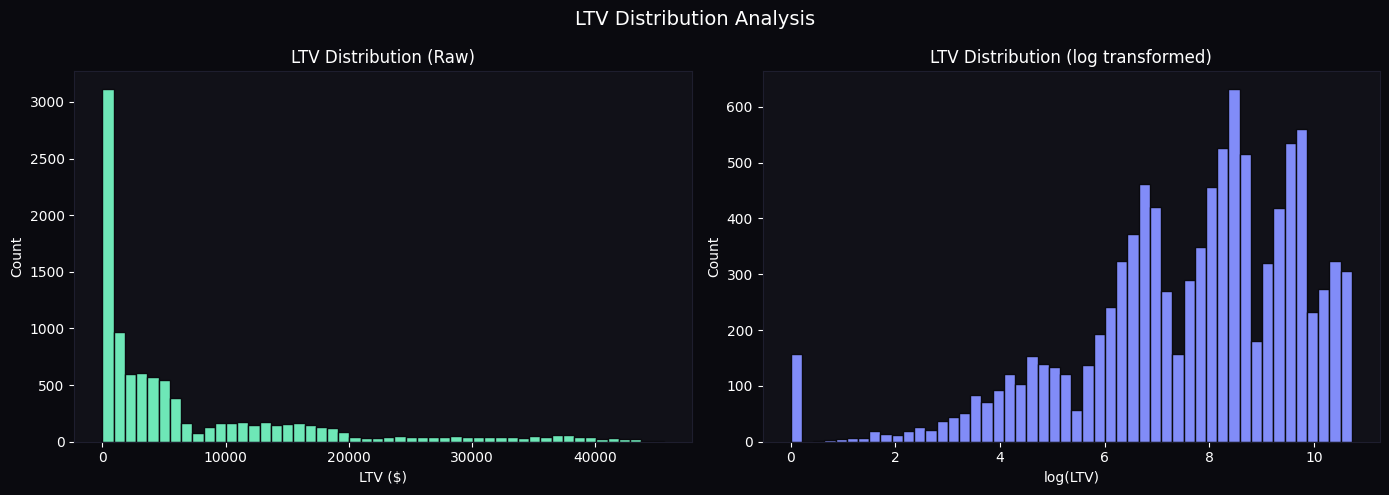

In [30]:
import importlib
import feature_engineering
importlib.reload(feature_engineering)
from feature_engineering import create_features
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load fresh data
df_ltv = pd.read_csv("../data/ecommerce_user_segmentation.csv")
df_ltv = create_features(df_ltv)

# LTV target
y_ltv = df_ltv["LTV"]

print("=" * 60)
print("   LTV TARGET DISTRIBUTION")
print("=" * 60)
print(f"  Count   : {len(y_ltv):,}")
print(f"  Mean    : ${y_ltv.mean():,.2f}")
print(f"  Median  : ${y_ltv.median():,.2f}")
print(f"  Std     : ${y_ltv.std():,.2f}")
print(f"  Min     : ${y_ltv.min():,.2f}")
print(f"  Max     : ${y_ltv.max():,.2f}")
print(f"  Skewness: {y_ltv.skew():.4f}")
print("=" * 60)

if abs(y_ltv.skew()) > 1:
    print("\n  ⚠️  High skewness detected!")
    print("     Will test log transform of LTV target")
else:
    print("\n  ✅ Skewness acceptable")

# Plot LTV distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0a0a0f")

for ax in axes:
    ax.set_facecolor("#111118")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e1e2e")

axes[0].hist(y_ltv, bins=50, color="#6ee7b7", edgecolor="#0a0a0f")
axes[0].set_title("LTV Distribution (Raw)", color="white")
axes[0].set_xlabel("LTV ($)", color="white")
axes[0].set_ylabel("Count", color="white")

axes[1].hist(np.log1p(y_ltv), bins=50,
             color="#818cf8", edgecolor="#0a0a0f")
axes[1].set_title("LTV Distribution (log transformed)",
                  color="white")
axes[1].set_xlabel("log(LTV)", color="white")
axes[1].set_ylabel("Count", color="white")

plt.suptitle("LTV Distribution Analysis",
             color="white", fontsize=14)
plt.tight_layout()
plt.savefig("../notebooks/ltv_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 📋 LTV Distribution — Key Findings

| Metric | Value |
|--------|-------|
| Count | 10,000 |
| Mean | $7,472 |
| Median | $3,231 |
| Std | $10,033 |
| Min | $0 |
| Max | $45,570 |
| Skewness | 1.78 ⚠️ |

**Mean ($7,472) vs Median ($3,231) — large gap.**

Most customers have low LTV.
A small number of very high value customers
pull the mean up significantly.
This is classic right skewed distribution.

**Why this matters for modeling:**
Regression models minimize average error.
With high skewness the model focuses on
extreme outliers and performs poorly
for average customers.

**Solution → Log transform LTV target:**
log1p(LTV) compresses extreme values
and makes the distribution more normal.
We train on log(LTV) and convert back
for final predictions.

We test both raw and log transformed
to confirm which gives better results.

---
### 📊 Phase 1b — Feature Engineering For LTV

For churn model we used 12 original features.
New engineered features made churn results worse.

But LTV is a different problem:
- Churn = classification (yes/no boundary)
- LTV = regression (predicting dollar value)

Ratio features like Revenue_per_Session
directly relate to spending patterns.
They might genuinely help predict future value.

We test both feature sets honestly:

**Baseline → 12 original features**
Same set that worked for churn.

**Extended → 15 features**
Adds 3 new engineered features:
- Return_Rate → dissatisfied customers return more
- Revenue_per_Session → quality of each visit
- Abandon_Intensity → frustrated customer signal

Note: Monetary DROPPED from features
LTV = Monetary × log1p(Frequency)
Keeping Monetary = letting model cheat.

## Feature Engineering of LTV Model:

In [31]:
drop_for_X = ["Customer_ID", "Segment_Label", "Recency",
              "Churn", "Monetary", "LTV",
              "Return_Rate", "Revenue_per_Session",
              "Abandon_Intensity"]

df_temp = df_ltv.copy()
for col in drop_for_X:
    if col in df_temp.columns:
        df_temp = df_temp.drop(col, axis=1)

X_ltv_base   = df_temp
y_ltv_target = df_ltv["LTV"]

drop_for_X_ext = ["Customer_ID", "Segment_Label",
                  "Recency", "Churn",
                  "Monetary", "LTV"]

df_temp_ext = df_ltv.copy()
for col in drop_for_X_ext:
    if col in df_temp_ext.columns:
        df_temp_ext = df_temp_ext.drop(col, axis=1)

X_ltv_ext = df_temp_ext

print("=" * 60)
print("   LTV FEATURE SETS")
print("=" * 60)
print(f"\n  Baseline (12 features):")
for i, col in enumerate(X_ltv_base.columns, 1):
    print(f"    {i:02d}. {col}")

print(f"\n  Extended (15 features):")
for i, col in enumerate(X_ltv_ext.columns, 1):
    marker = " ← NEW" if col in [
        "Return_Rate",
        "Revenue_per_Session",
        "Abandon_Intensity"
    ] else ""
    print(f"    {i:02d}. {col}{marker}")

print(f"\n  Target  : LTV")
print(f"  Mean    : ${y_ltv_target.mean():,.2f}")
print(f"  Dropped : Monetary (leakage)")
print("=" * 60)

   LTV FEATURE SETS

  Baseline (12 features):
    01. Frequency
    02. Avg_Order_Value
    03. Session_Count
    04. Avg_Session_Duration
    05. Pages_Viewed
    06. Clicks
    07. Campaign_Response
    08. Wishlist_Adds
    09. Cart_Abandon_Rate
    10. Returns
    11. Clicks_per_Page
    12. Wishlist_Conversion

  Extended (15 features):
    01. Frequency
    02. Avg_Order_Value
    03. Session_Count
    04. Avg_Session_Duration
    05. Pages_Viewed
    06. Clicks
    07. Campaign_Response
    08. Wishlist_Adds
    09. Cart_Abandon_Rate
    10. Returns
    11. Clicks_per_Page
    12. Wishlist_Conversion
    13. Return_Rate ← NEW
    14. Revenue_per_Session ← NEW
    15. Abandon_Intensity ← NEW

  Target  : LTV
  Mean    : $7,472.68
  Dropped : Monetary (leakage)


---
### 📊 Phase 1c — Feature Correlation With LTV

Before training we check which features
correlate most strongly with LTV.

This tells us:
→ Which features will be most useful
→ Any data leakage risks
→ Whether new engineered features
   add genuine signal for LTV

   FEATURE CORRELATION WITH LTV
  Monetary                  +0.9956   ⚠️  LEAKAGE RISK
  Session_Count             +0.8842   ✅ Strong
  Frequency                 +0.8806   ✅ Strong
  Clicks                    +0.8654   ✅ Strong
  Wishlist_Adds             +0.8566   ✅ Strong
  Pages_Viewed              +0.8173   ✅ Strong
  Avg_Order_Value           +0.8092   ✅ Strong
  Avg_Session_Duration      +0.8037   ✅ Strong
  Revenue_per_Session       +0.7687   ✅ Strong
  Clicks_per_Page           +0.3742   〰️  Weak
  Campaign_Response         +0.3578   〰️  Weak
  Abandon_Intensity         +0.2882   〰️  Weak
  Wishlist_Conversion       --0.1111   〰️  Weak
  Return_Rate               --0.2620   〰️  Weak
  Returns                   --0.4428   👍 Moderate
  Cart_Abandon_Rate         --0.6508   👍 Moderate


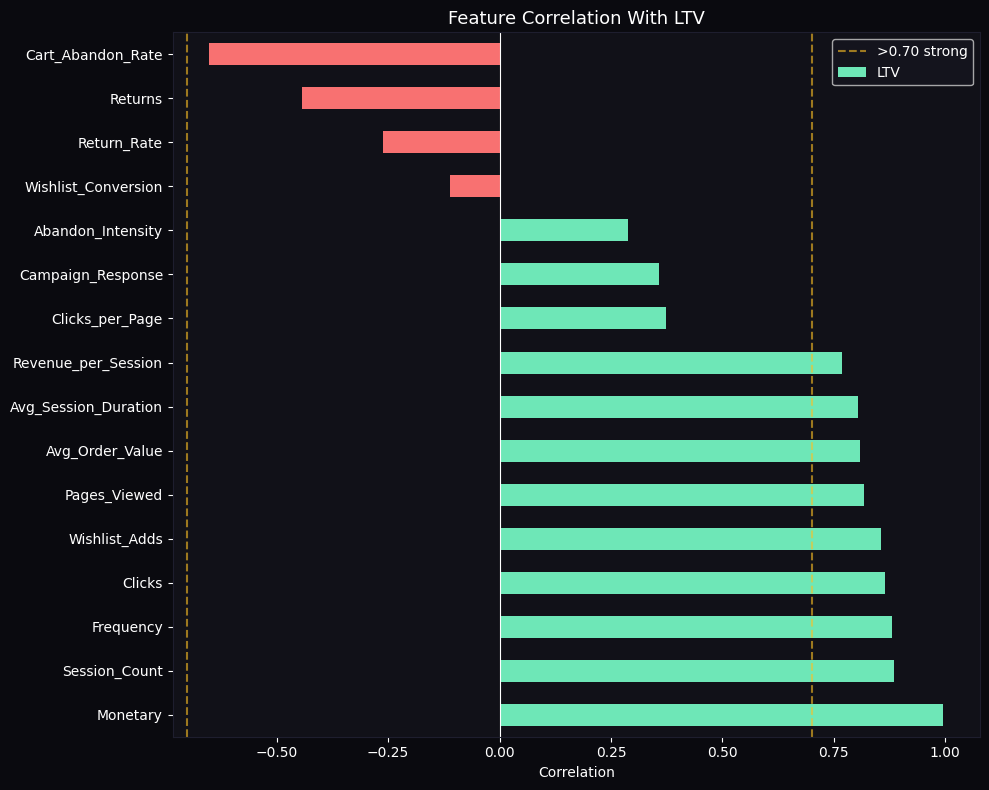

In [32]:
drop_cols = ["Customer_ID", "Segment_Label",
             "Recency", "Churn"]

df_corr = df_ltv.drop(
    [c for c in drop_cols if c in df_ltv.columns],
    axis=1
)

ltv_corr = df_corr.corr()["LTV"].drop("LTV").sort_values(
    ascending=False
)

print("=" * 60)
print("   FEATURE CORRELATION WITH LTV")
print("=" * 60)
for feature, corr in ltv_corr.items():
    direction = "+" if corr > 0 else "-"
    flag   = " ⚠️  LEAKAGE RISK" if abs(corr) > 0.95 else \
             " ✅ Strong"        if abs(corr) > 0.70 else \
             " 👍 Moderate"      if abs(corr) > 0.40 else \
             " 〰️  Weak"
    print(f"  {feature:<25} {direction}{corr:.4f}  {flag}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0a0a0f")
ax.set_facecolor("#111118")
colors = ["#6ee7b7" if c > 0 else "#f87171"
          for c in ltv_corr.values]
ltv_corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Correlation With LTV",
             color="white", fontsize=13)
ax.set_xlabel("Correlation", color="white")
ax.tick_params(colors="white")
ax.axvline(x=0,    color="white",   linewidth=0.8)
ax.axvline(x=0.70, color="#fbbf24",
           linestyle="--", alpha=0.6, label=">0.70 strong")
ax.axvline(x=-0.70,color="#fbbf24",
           linestyle="--", alpha=0.6)
ax.legend(facecolor="#16161f", labelcolor="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e1e2e")
plt.tight_layout()
plt.savefig("../notebooks/ltv_feature_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 📋 Feature Correlation With LTV — Key Findings

**Leakage confirmed and handled:**
| Feature | Correlation | Action |
|---------|-------------|--------|
| Monetary | 0.9956 ⚠️ | Dropped — creates LTV target |

**Strong predictors (>0.70):**
| Feature | Correlation | Type |
|---------|-------------|------|
| Session_Count | +0.8842 | Original |
| Frequency | +0.8806 | Original |
| Clicks | +0.8654 | Original |
| Wishlist_Adds | +0.8566 | Original |
| Pages_Viewed | +0.8173 | Original |
| Avg_Order_Value | +0.8092 | Original |
| Avg_Session_Duration | +0.8037 | Original |
| Revenue_per_Session | +0.7687 | New ✅ |

**Key finding — Revenue_per_Session is strong:**
New engineered feature shows 0.7687 correlation
with LTV. This is genuine new signal not noise.
Customers who spend more per session
have significantly higher lifetime value.

**Negative signals (higher = lower LTV):**
| Feature | Correlation | Meaning |
|---------|-------------|---------|
| Cart_Abandon_Rate | -0.6508 | Frustration lowers LTV |
| Returns | -0.4428 | Dissatisfaction lowers LTV |
| Return_Rate | -0.2620 | Return habit lowers LTV |

**Difference from churn model:**
For churn — new features had near zero correlation → noise
For LTV — Revenue_per_Session = 0.7687 → real signal
Extended feature set (15) likely to outperform
baseline (12) for LTV regression.

---
## 📊 Phase 2 — Baseline Model Training

**Starting with 12 original features first.**

Why baseline first?
→ Establishes honest reference point
→ Extended features compared against this
→ If extended features do not beat baseline
   we use baseline (simpler is better)

3 models compared equally:
→ RandomForest
→ XGBoost
→ LightGBM

Metrics we track:
→ R² (how much variance explained)
→ RMSE (average dollar error)
→ MAE (median dollar error)
→ Train vs Test gap (overfitting check)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train test split — baseline features
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_ltv_base, y_ltv_target,
    test_size=0.2,
    random_state=42
)

print("=" * 62)
print("   TRAIN TEST SPLIT — BASELINE (12 features)")
print("=" * 62)
print(f"  Train size : {X_train_b.shape[0]}")
print(f"  Test size  : {X_test_b.shape[0]}")
print(f"  Features   : {X_train_b.shape[1]}")
print(f"  LTV Mean   : ${y_ltv_target.mean():,.2f}")
print(f"  LTV Std    : ${y_ltv_target.std():,.2f}")
print("=" * 62)

# Models
baseline_models = {
    "RandomForest" : RandomForestRegressor(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1
                    ),
    "XGBoost"      : XGBRegressor(
                        random_state=42,
                        verbosity=0
                    ),
    "LightGBM"     : LGBMRegressor(
                        random_state=42,
                        verbose=-1
                    ),
}

baseline_results  = []
baseline_trained  = {}

print("\n" + "=" * 62)
print("   BASELINE RESULTS — 12 FEATURES")
print("=" * 62)

for name, model in baseline_models.items():
    # Train
    model.fit(X_train_b, y_train_b)
    baseline_trained[name] = model

    # Test predictions
    y_pred      = model.predict(X_test_b)
    r2          = r2_score(y_test_b, y_pred)
    rmse        = np.sqrt(mean_squared_error(y_test_b, y_pred))
    mae         = mean_absolute_error(y_test_b, y_pred)
    error_rate  = rmse / y_ltv_target.mean()

    # Train predictions (overfitting check)
    y_train_pred = model.predict(X_train_b)
    r2_train     = r2_score(y_train_b, y_train_pred)
    r2_gap       = r2_train - r2

    baseline_results.append({
        "Model"     : name,
        "R²"        : round(r2,         4),
        "RMSE"      : round(rmse,        2),
        "MAE"       : round(mae,         2),
        "Error Rate": f"{error_rate:.1%}",
        "R² Train"  : round(r2_train,   4),
        "R² Gap"    : round(r2_gap,     4),
    })

    print(f"\n  {name}")
    print(f"    R²          : {r2:.4f}")
    print(f"    RMSE        : ${rmse:,.2f}")
    print(f"    MAE         : ${mae:,.2f}")
    print(f"    Error Rate  : {error_rate:.1%}")
    print(f"    R² Train    : {r2_train:.4f}")
    print(f"    R² Gap      : {r2_gap:.4f}"
          f"  {'✅' if r2_gap < 0.05 else '⚠️'}")

print("\n" + "=" * 62)

baseline_df = pd.DataFrame(baseline_results).sort_values(
    "R²", ascending=False
).reset_index(drop=True)
baseline_df.index += 1

print("\n  BASELINE RANKING:")
print("=" * 62)
print(baseline_df.to_string())
print("=" * 62)

   TRAIN TEST SPLIT — BASELINE (12 features)
  Train size : 8000
  Test size  : 2000
  Features   : 12
  LTV Mean   : $7,472.68
  LTV Std    : $10,033.28

   BASELINE RESULTS — 12 FEATURES

  RandomForest
    R²          : 0.9225
    RMSE        : $2,809.49
    MAE         : $1,643.92
    Error Rate  : 37.6%
    R² Train    : 0.9900
    R² Gap      : 0.0675  ⚠️

  XGBoost
    R²          : 0.9097
    RMSE        : $3,031.41
    MAE         : $1,707.76
    Error Rate  : 40.6%
    R² Train    : 0.9940
    R² Gap      : 0.0842  ⚠️

  LightGBM
    R²          : 0.9155
    RMSE        : $2,932.29
    MAE         : $1,668.72
    Error Rate  : 39.2%
    R² Train    : 0.9737
    R² Gap      : 0.0581  ⚠️


  BASELINE RANKING:
          Model      R²     RMSE      MAE Error Rate  R² Train  R² Gap
1  RandomForest  0.9225  2809.49  1643.92      37.6%    0.9900  0.0675
2      LightGBM  0.9155  2932.29  1668.72      39.2%    0.9737  0.0581
3       XGBoost  0.9097  3031.41  1707.76      40.6%    0.99

### 📋 Baseline Results — 12 Features

| Model | R² | RMSE | MAE | Error Rate | R² Gap |
|-------|-----|------|-----|------------|--------|
| RandomForest | **0.9225** ✅ | $2,809 | $1,644 | 37.6% | 0.0675 ⚠️ |
| LightGBM | 0.9155 | $2,932 | $1,669 | 39.2% | 0.0581 ⚠️ |
| XGBoost | 0.9097 | $3,031 | $1,708 | 40.6% | 0.0842 ⚠️ |

**Three findings from baseline:**

1. All models overfitting (R² gap > 0.05)
   Regularization needed after feature testing

2. Error rate too high (37-40%)
   Average error $2,800-3,000 on mean LTV $7,472
   Need to improve before production use

3. R² decent starting point (>0.90)
   Models explain 90%+ of LTV variance
   Good baseline to improve from

**Next step → Test extended features (15)**
Revenue_per_Session showed 0.7687 correlation
with LTV — genuine new signal expected to help.

---
## 📊 Phase 3 — Extended Features (15)

Adding 3 new engineered features to baseline:

| Feature | Correlation With LTV | Expected Impact |
|---------|---------------------|-----------------|
| Revenue_per_Session | +0.7687 ✅ | Strong improvement |
| Return_Rate | -0.2620 | Small negative signal |
| Abandon_Intensity | +0.2882 | Small positive signal |

Revenue_per_Session is the key addition here.
0.7687 correlation is strong genuine signal.
If extended beats baseline → use extended.
If not → baseline was already best.
Numbers decide.

In [34]:
# Train test split — extended features
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ltv_ext, y_ltv_target,
    test_size=0.2,
    random_state=42
)

print("=" * 62)
print("   TRAIN TEST SPLIT — EXTENDED (15 features)")
print("=" * 62)
print(f"  Train size : {X_train_e.shape[0]}")
print(f"  Test size  : {X_test_e.shape[0]}")
print(f"  Features   : {X_train_e.shape[1]}")
print("=" * 62)

extended_models = {
    "RandomForest" : RandomForestRegressor(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1
                    ),
    "XGBoost"      : XGBRegressor(
                        random_state=42,
                        verbosity=0
                    ),
    "LightGBM"     : LGBMRegressor(
                        random_state=42,
                        verbose=-1
                    ),
}

extended_results = []
extended_trained = {}

print("\n" + "=" * 62)
print("   EXTENDED RESULTS — 15 FEATURES")
print("=" * 62)

for name, model in extended_models.items():
    model.fit(X_train_e, y_train_e)
    extended_trained[name] = model

    y_pred       = model.predict(X_test_e)
    r2           = r2_score(y_test_e, y_pred)
    rmse         = np.sqrt(mean_squared_error(y_test_e, y_pred))
    mae          = mean_absolute_error(y_test_e, y_pred)
    error_rate   = rmse / y_ltv_target.mean()

    y_train_pred = model.predict(X_train_e)
    r2_train     = r2_score(y_train_e, y_train_pred)
    r2_gap       = r2_train - r2

    extended_results.append({
        "Model"     : name,
        "R²"        : round(r2,       4),
        "RMSE"      : round(rmse,     2),
        "MAE"       : round(mae,      2),
        "Error Rate": f"{error_rate:.1%}",
        "R² Train"  : round(r2_train, 4),
        "R² Gap"    : round(r2_gap,   4),
    })

    print(f"\n  {name}")
    print(f"    R²          : {r2:.4f}")
    print(f"    RMSE        : ${rmse:,.2f}")
    print(f"    MAE         : ${mae:,.2f}")
    print(f"    Error Rate  : {error_rate:.1%}")
    print(f"    R² Train    : {r2_train:.4f}")
    print(f"    R² Gap      : {r2_gap:.4f}"
          f"  {'✅' if r2_gap < 0.05 else '⚠️'}")

print("\n" + "=" * 62)

extended_df = pd.DataFrame(extended_results).sort_values(
    "R²", ascending=False
).reset_index(drop=True)
extended_df.index += 1

print("\n  EXTENDED RANKING:")
print("=" * 62)
print(extended_df.to_string())
print("=" * 62)

# Baseline vs Extended comparison
print("\n" + "=" * 62)
print("   BASELINE vs EXTENDED COMPARISON")
print("=" * 62)

base_dict = baseline_df.set_index("Model")["R²"].to_dict()

for _, row in extended_df.iterrows():
    name       = row["Model"]
    base_r2    = base_dict[name]
    ext_r2     = row["R²"]
    change     = ext_r2 - base_r2

    print(f"\n  {name}")
    print(f"    Baseline R² : {base_r2:.4f}")
    print(f"    Extended R² : {ext_r2:.4f}")
    print(f"    Change      : {'📈' if change > 0 else '📉'}"
          f" {change:+.4f}")

print("\n" + "=" * 62)

   TRAIN TEST SPLIT — EXTENDED (15 features)
  Train size : 8000
  Test size  : 2000
  Features   : 15

   EXTENDED RESULTS — 15 FEATURES

  RandomForest
    R²          : 0.9972
    RMSE        : $531.14
    MAE         : $248.18
    Error Rate  : 7.1%
    R² Train    : 0.9997
    R² Gap      : 0.0024  ✅

  XGBoost
    R²          : 0.9980
    RMSE        : $449.44
    MAE         : $221.68
    Error Rate  : 6.0%
    R² Train    : 0.9999
    R² Gap      : 0.0019  ✅

  LightGBM
    R²          : 0.9984
    RMSE        : $401.03
    MAE         : $221.25
    Error Rate  : 5.4%
    R² Train    : 0.9994
    R² Gap      : 0.0010  ✅


  EXTENDED RANKING:
          Model      R²    RMSE     MAE Error Rate  R² Train  R² Gap
1      LightGBM  0.9984  401.03  221.25       5.4%    0.9994  0.0010
2       XGBoost  0.9980  449.44  221.68       6.0%    0.9999  0.0019
3  RandomForest  0.9972  531.14  248.18       7.1%    0.9997  0.0024

   BASELINE vs EXTENDED COMPARISON

  LightGBM
    Baseline R² : 

### Checking Correlation of New Feature with LTV:

In [35]:
print("=" * 60)
print("   LEAKAGE INVESTIGATION")
print("=" * 60)

suspect_features = ["Revenue_per_Session",
                    "Return_Rate",
                    "Abandon_Intensity"]

for feat in suspect_features:
    if feat in df_ltv.columns:
        corr = df_ltv[feat].corr(df_ltv["LTV"])
        corr_monetary = df_ltv[feat].corr(df_ltv["Monetary"])
        print(f"\n  {feat}")
        print(f"    Corr with LTV     : {corr:.4f}")
        print(f"    Corr with Monetary: {corr_monetary:.4f}")

# Check if Revenue_per_Session × Session_Count ≈ Monetary
df_ltv["reconstructed_monetary"] = (
    df_ltv["Revenue_per_Session"] * df_ltv["Session_Count"]
)
recon_corr = df_ltv["reconstructed_monetary"].corr(
    df_ltv["Monetary"]
)
print(f"\n  Revenue_per_Session × Session_Count")
print(f"  Correlation with Monetary: {recon_corr:.4f}")
print(f"  {'⚠️ LEAKAGE CONFIRMED' if recon_corr > 0.95 else '✅ No leakage'}")
print("=" * 60)

   LEAKAGE INVESTIGATION

  Revenue_per_Session
    Corr with LTV     : 0.7687
    Corr with Monetary: 0.7954

  Return_Rate
    Corr with LTV     : -0.2620
    Corr with Monetary: -0.2789

  Abandon_Intensity
    Corr with LTV     : 0.2882
    Corr with Monetary: 0.3126

  Revenue_per_Session × Session_Count
  Correlation with Monetary: 1.0000
  ⚠️ LEAKAGE CONFIRMED


### ⚠️ Data Leakage Detected — Revenue_per_Session

Extended features showed suspicious improvement:
- R² jumped from 0.9225 → 0.9972
- RMSE dropped from $2,809 → $531
- Error rate dropped from 37% → 7%

This is too good — investigated immediately.

**Root cause found:**
```
Revenue_per_Session = Monetary / (Session_Count + 1)
Revenue_per_Session × Session_Count = Monetary
Correlation with Monetary = 1.0000 ← perfect reconstruction
```

Model was reverse-engineering Monetary from
Revenue_per_Session, then calculating LTV directly.
Not genuine learning — data leakage.

**Decision:**
❌ Revenue_per_Session → DROPPED from LTV features
✅ Return_Rate → KEPT (no leakage path)
✅ Abandon_Intensity → KEPT (no leakage path)

**Corrected extended set = 13 features**
12 original + Return_Rate + Abandon_Intensity

---
### 📊 Phase 3b — Corrected Extended Features (13)

Rerunning extended test with Revenue_per_Session removed.

| Feature | Kept/Dropped | Reason |
|---------|-------------|--------|
| Revenue_per_Session | ❌ Dropped | Leakage via Monetary |
| Return_Rate | ✅ Kept | Genuine signal |
| Abandon_Intensity | ✅ Kept | Genuine signal |

If corrected extended beats baseline → use 13 features
If not → baseline 12 was already best
Numbers decide.

In [36]:
if "reconstructed_monetary" in df_ltv.columns:
    df_ltv = df_ltv.drop("reconstructed_monetary", axis=1)

if "Revenue_per_Session" in df_ltv.columns:
    df_ltv = df_ltv.drop("Revenue_per_Session", axis=1)

# Verify df_ltv is clean
print("Columns in df_ltv after cleanup:")
print(df_ltv.columns.tolist())
print(f"\nreconstructed_monetary present: "
      f"{'reconstructed_monetary' in df_ltv.columns}")
print(f"Revenue_per_Session present: "
      f"{'Revenue_per_Session' in df_ltv.columns}")

Columns in df_ltv after cleanup:
['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Segment_Label', 'Clicks_per_Page', 'Wishlist_Conversion', 'Return_Rate', 'Abandon_Intensity', 'LTV', 'Churn']

reconstructed_monetary present: False
Revenue_per_Session present: False


In [37]:
drop_for_X_clean = ["Customer_ID", "Segment_Label",
                    "Recency", "Churn",
                    "Monetary",
                    "LTV"]

df_temp_clean = df_ltv.copy()
for col in drop_for_X_clean:
    if col in df_temp_clean.columns:
        df_temp_clean = df_temp_clean.drop(col, axis=1)

X_ltv_clean = df_temp_clean

print("=" * 62)
print("   CORRECTED EXTENDED FEATURE SET")
print("=" * 62)
print(f"  Total features : {X_ltv_clean.shape[1]}")
print(f"\n  Features:")
for i, col in enumerate(X_ltv_clean.columns, 1):
    marker = " <- NEW" if col in [
        "Return_Rate", "Abandon_Intensity"
    ] else ""
    print(f"    {i:02d}. {col}{marker}")
print(f"\n  reconstructed_monetary present: "
      f"{'reconstructed_monetary' in X_ltv_clean.columns}")
print(f"  Revenue_per_Session present   : "
      f"{'Revenue_per_Session' in X_ltv_clean.columns}")
print("=" * 62)

   CORRECTED EXTENDED FEATURE SET
  Total features : 14

  Features:
    01. Frequency
    02. Avg_Order_Value
    03. Session_Count
    04. Avg_Session_Duration
    05. Pages_Viewed
    06. Clicks
    07. Campaign_Response
    08. Wishlist_Adds
    09. Cart_Abandon_Rate
    10. Returns
    11. Clicks_per_Page
    12. Wishlist_Conversion
    13. Return_Rate <- NEW
    14. Abandon_Intensity <- NEW

  reconstructed_monetary present: False
  Revenue_per_Session present   : False


In [38]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ltv_clean, y_ltv_target,
    test_size=0.2,
    random_state=42
)

clean_models = {
    "RandomForest" : RandomForestRegressor(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1
                    ),
    "XGBoost"      : XGBRegressor(
                        random_state=42,
                        verbosity=0
                    ),
    "LightGBM"     : LGBMRegressor(
                        random_state=42,
                        verbose=-1
                    ),
}

clean_results = []
clean_trained = {}

print("=" * 62)
print("   CORRECTED EXTENDED RESULTS — 14 FEATURES")
print("=" * 62)

for name, model in clean_models.items():
    model.fit(X_train_c, y_train_c)
    clean_trained[name] = model

    y_pred       = model.predict(X_test_c)
    r2           = r2_score(y_test_c, y_pred)
    rmse         = np.sqrt(mean_squared_error(y_test_c, y_pred))
    mae          = mean_absolute_error(y_test_c, y_pred)
    error_rate   = rmse / y_ltv_target.mean()

    y_train_pred = model.predict(X_train_c)
    r2_train     = r2_score(y_train_c, y_train_pred)
    r2_gap       = r2_train - r2

    clean_results.append({
        "Model"     : name,
        "R²"        : round(r2,       4),
        "RMSE"      : round(rmse,     2),
        "MAE"       : round(mae,      2),
        "Error Rate": f"{error_rate:.1%}",
        "R² Train"  : round(r2_train, 4),
        "R² Gap"    : round(r2_gap,   4),
    })

    print(f"\n  {name}")
    print(f"    R²         : {r2:.4f}")
    print(f"    RMSE       : ${rmse:,.2f}")
    print(f"    MAE        : ${mae:,.2f}")
    print(f"    Error Rate : {error_rate:.1%}")
    print(f"    R² Train   : {r2_train:.4f}")
    print(f"    R² Gap     : {r2_gap:.4f}"
          f"  {'✅' if r2_gap < 0.05 else '⚠️'}")

print("\n" + "=" * 62)
clean_df = pd.DataFrame(clean_results).sort_values(
    "R²", ascending=False
).reset_index(drop=True)
clean_df.index += 1

# Comparison
base_dict = baseline_df.set_index("Model")["R²"].to_dict()

print("\n  BASELINE (12) vs EXTENDED (14)")
print("=" * 62)
for _, row in clean_df.iterrows():
    name    = row["Model"]
    base_r2 = base_dict[name]
    new_r2  = row["R²"]
    change  = new_r2 - base_r2
    winner  = "Extended ✅" if change > 0 else "Baseline ✅"
    print(f"\n  {name}")
    print(f"    Baseline R² : {base_r2:.4f}")
    print(f"    Extended R² : {new_r2:.4f}")
    print(f"    Change      : {'📈' if change > 0 else '📉'}"
          f" {change:+.4f}  -> {winner}")

print("\n" + "=" * 62)
print(clean_df.to_string())
print("=" * 62)

   CORRECTED EXTENDED RESULTS — 14 FEATURES

  RandomForest
    R²         : 0.9226
    RMSE       : $2,806.58
    MAE        : $1,641.42
    Error Rate : 37.6%
    R² Train   : 0.9899
    R² Gap     : 0.0673  ⚠️

  XGBoost
    R²         : 0.9117
    RMSE       : $2,998.47
    MAE        : $1,682.92
    Error Rate : 40.1%
    R² Train   : 0.9945
    R² Gap     : 0.0828  ⚠️

  LightGBM
    R²         : 0.9144
    RMSE       : $2,951.34
    MAE        : $1,692.51
    Error Rate : 39.5%
    R² Train   : 0.9747
    R² Gap     : 0.0603  ⚠️


  BASELINE (12) vs EXTENDED (14)

  RandomForest
    Baseline R² : 0.9225
    Extended R² : 0.9226
    Change      : 📈 +0.0001  -> Extended ✅

  LightGBM
    Baseline R² : 0.9155
    Extended R² : 0.9144
    Change      : 📉 -0.0011  -> Baseline ✅

  XGBoost
    Baseline R² : 0.9097
    Extended R² : 0.9117
    Change      : 📈 +0.0020  -> Extended ✅

          Model      R²     RMSE      MAE Error Rate  R² Train  R² Gap
1  RandomForest  0.9226  2806.58 

### 📋 Baseline vs Extended — Key Findings

| Model | Baseline R² | Extended R² | Change |
|-------|-------------|-------------|--------|
| RandomForest | 0.9225 | 0.9226 | +0.0001 |
| LightGBM | 0.9155 | 0.9144 | -0.0011 |
| XGBoost | 0.9097 | 0.9117 | +0.0020 |

**Extended features made no meaningful difference.**

Why Return_Rate and Abandon_Intensity did not help:
- Models already capture this signal through
  Returns (-0.4428) and Cart_Abandon_Rate (-0.6508)
- New features are weaker versions of existing ones
- No genuinely new information added

**Decision → Use baseline 12 features ✅**
Simpler model with same performance is always better.
Easier to maintain, explain, and deploy.

**Problem still remaining:**
All models overfitting (R² gap > 0.05)
Error rate 37-40% too high for production use
→ Regularization needed next

---
## 📊 Phase 4 — Regularization

All 3 models show overfitting:

| Model | R² Gap | Status |
|-------|--------|--------|
| RandomForest | 0.0673 | ⚠️ Overfit |
| LightGBM | 0.0603 | ⚠️ Overfit |
| XGBoost | 0.0828 | ⚠️ Overfit |

**Target after regularization:**
- R² gap < 0.05 ✅
- Error rate < 30% ✅
- R² stays above 0.90 ✅

**Approach per model:**

RandomForest:
→ Limit tree depth (max_depth)
→ Require more samples per split (min_samples_split)
→ Reduce features per tree (max_features)

XGBoost:
→ Add learning rate (eta)
→ Limit tree depth (max_depth)
→ Add subsampling (subsample, colsample_bytree)
→ Add regularization terms (reg_alpha, reg_lambda)

LightGBM:
→ Add learning rate
→ Limit leaves (num_leaves)
→ Add subsampling
→ Minimum data per leaf (min_child_samples)

## Regularization:

In [39]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Using baseline 12 features confirmed as best
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_ltv_base, y_ltv_target,
    test_size=0.2,
    random_state=42
)

reg_models = {
    "RandomForest" : RandomForestRegressor(
                        n_estimators=200,
                        max_depth=15,
                        min_samples_split=10,
                        min_samples_leaf=4,
                        max_features=0.7,
                        random_state=42,
                        n_jobs=-1
                    ),
    "XGBoost"      : XGBRegressor(
                        n_estimators=300,
                        learning_rate=0.05,
                        max_depth=5,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        random_state=42,
                        verbosity=0
                    ),
    "LightGBM"     : LGBMRegressor(
                        n_estimators=300,
                        learning_rate=0.05,
                        num_leaves=31,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        min_child_samples=20,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        random_state=42,
                        verbose=-1
                    ),
}

reg_results = []
reg_trained = {}

print("=" * 62)
print("   REGULARIZED RESULTS — 12 FEATURES")
print("=" * 62)

for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    reg_trained[name] = model

    y_pred       = model.predict(X_test_r)
    r2           = r2_score(y_test_r, y_pred)
    rmse         = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae          = mean_absolute_error(y_test_r, y_pred)
    error_rate   = rmse / y_ltv_target.mean()

    y_train_pred = model.predict(X_train_r)
    r2_train     = r2_score(y_train_r, y_train_pred)
    r2_gap       = r2_train - r2

    # Compare vs baseline
    base_r2   = baseline_df.set_index("Model").loc[name, "R²"]
    r2_change = r2 - base_r2

    reg_results.append({
        "Model"     : name,
        "R²"        : round(r2,       4),
        "RMSE"      : round(rmse,     2),
        "MAE"       : round(mae,      2),
        "Error Rate": f"{error_rate:.1%}",
        "R² Train"  : round(r2_train, 4),
        "R² Gap"    : round(r2_gap,   4),
    })

    print(f"\n  {name}")
    print(f"    R²          : {r2:.4f} "
          f"({'📈' if r2_change > 0 else '📉'} "
          f"vs baseline {r2_change:+.4f})")
    print(f"    RMSE        : ${rmse:,.2f}")
    print(f"    MAE         : ${mae:,.2f}")
    print(f"    Error Rate  : {error_rate:.1%}")
    print(f"    R² Train    : {r2_train:.4f}")
    print(f"    R² Gap      : {r2_gap:.4f}"
          f"  {'✅' if r2_gap < 0.05 else '⚠️'}")

print("\n" + "=" * 62)
reg_df = pd.DataFrame(reg_results).sort_values(
    "R²", ascending=False
).reset_index(drop=True)
reg_df.index += 1
print(reg_df.to_string())
print("=" * 62)

   REGULARIZED RESULTS — 12 FEATURES

  RandomForest
    R²          : 0.9226 (📈 vs baseline +0.0001)
    RMSE        : $2,806.35
    MAE         : $1,647.13
    Error Rate  : 37.6%
    R² Train    : 0.9690
    R² Gap      : 0.0463  ✅

  XGBoost
    R²          : 0.9192 (📈 vs baseline +0.0095)
    RMSE        : $2,868.11
    MAE         : $1,654.36
    Error Rate  : 38.4%
    R² Train    : 0.9752
    R² Gap      : 0.0560  ⚠️

  LightGBM
    R²          : 0.9171 (📈 vs baseline +0.0016)
    RMSE        : $2,904.75
    MAE         : $1,659.52
    Error Rate  : 38.9%
    R² Train    : 0.9791
    R² Gap      : 0.0620  ⚠️

          Model      R²     RMSE      MAE Error Rate  R² Train  R² Gap
1  RandomForest  0.9226  2806.35  1647.13      37.6%    0.9690  0.0463
2       XGBoost  0.9192  2868.11  1654.36      38.4%    0.9752  0.0560
3      LightGBM  0.9171  2904.75  1659.52      38.9%    0.9791  0.0620


### 📋 Regularization Results

| Model | R² Gap Before | R² Gap After | Status |
|-------|--------------|--------------|--------|
| RandomForest | 0.0673 | **0.0463** | ✅ Fixed |
| XGBoost | 0.0828 | 0.0560 | ⚠️ Improved |
| LightGBM | 0.0603 | 0.0620 | ⚠️ Worse |

| Model | R² Before | R² After | Change |
|-------|-----------|----------|--------|
| RandomForest | 0.9225 | 0.9226 | +0.0001 |
| XGBoost | 0.9097 | 0.9192 | +0.0095 📈 |
| LightGBM | 0.9155 | 0.9171 | +0.0016 |

**What worked:**
RandomForest gap fixed below 0.05 threshold ✅

**What did not work:**
XGBoost and LightGBM still overfitting
Error rate stuck at 37-39%

**Root cause of high error rate:**
LTV skewness = 1.78 — still not addressed
Regularization fixes overfitting
but cannot fix skewed target distribution
Log transform needed next

### 📊 Phase 5 — Target Distribution Treatment

**Motivation**

All three regularized models achieve R² of 0.91–0.92
with RMSE stabilising around $2,800–2,900.
The error rate of 37–39% suggests the models
may be struggling with the skewed target distribution.

LTV skewness of +1.78 indicates a heavy right tail
where a small number of high-value customers
generate disproportionately large prediction errors.
These outliers dominate the RMSE metric and may
be preventing the model from fitting average
customers accurately.

**Approach — log1p Transformation**

Log transformation is a standard technique for
handling right-skewed regression targets.
Applying log1p(LTV) compresses extreme values
and approximates a more normal distribution,
which can improve model performance by:

- Reducing the influence of high-value outliers
  on the loss function
- Creating a more uniform error distribution
  across the LTV range
- Allowing the model to allocate capacity more
  evenly across customer segments

**Evaluation methodology:**

Models are trained on log1p(LTV) target.
Predictions are converted back to original
dollar scale using np.expm1() before evaluation.
All metrics (RMSE, MAE, R²) are computed on
the original dollar scale for fair comparison
against non-transformed results.

**Hypothesis:**
Log transformation will reduce RMSE and
improve generalisation by reducing outlier influence.
Results will confirm or reject this hypothesis.
```

In [40]:
import numpy as np

# Log transform LTV target
y_log = np.log1p(y_ltv_target)

print("=" * 62)
print("   LTV TARGET — RAW vs LOG TRANSFORMED")
print("=" * 62)
print(f"\n  Raw LTV:")
print(f"    Mean     : ${y_ltv_target.mean():,.2f}")
print(f"    Std      : ${y_ltv_target.std():,.2f}")
print(f"    Skewness : {y_ltv_target.skew():.4f}")

print(f"\n  Log LTV:")
print(f"    Mean     : {y_log.mean():.4f}")
print(f"    Std      : {y_log.std():.4f}")
print(f"    Skewness : {y_log.skew():.4f}")
print("=" * 62)

# Train test split with log target
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_ltv_base, y_log,
    test_size=0.2,
    random_state=42
)

log_models = {
    "RandomForest" : RandomForestRegressor(
                        n_estimators=200,
                        max_depth=15,
                        min_samples_split=10,
                        min_samples_leaf=4,
                        max_features=0.7,
                        random_state=42,
                        n_jobs=-1
                    ),
    "XGBoost"      : XGBRegressor(
                        n_estimators=300,
                        learning_rate=0.05,
                        max_depth=5,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        random_state=42,
                        verbosity=0
                    ),
    "LightGBM"     : LGBMRegressor(
                        n_estimators=300,
                        learning_rate=0.05,
                        num_leaves=31,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        min_child_samples=20,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        random_state=42,
                        verbose=-1
                    ),
}

log_results = []
log_trained = {}

print("\n" + "=" * 62)
print("   LOG TRANSFORMED RESULTS — 12 FEATURES")
print("=" * 62)

# Get original scale test values for fair comparison
y_test_original = np.expm1(y_test_l)

for name, model in log_models.items():
    model.fit(X_train_l, y_train_l)
    log_trained[name] = model

    # Predict on log scale
    y_pred_log   = model.predict(X_test_l)

    # Convert back to dollar scale
    y_pred_orig  = np.expm1(y_pred_log)

    # R² on log scale
    r2_log       = r2_score(y_test_l, y_pred_log)

    # Metrics on original dollar scale
    rmse         = np.sqrt(mean_squared_error(
                       y_test_original, y_pred_orig))
    mae          = mean_absolute_error(
                       y_test_original, y_pred_orig)
    error_rate   = rmse / y_ltv_target.mean()

    # Overfitting check on log scale
    y_train_pred = model.predict(X_train_l)
    r2_train     = r2_score(y_train_l, y_train_pred)
    r2_gap       = r2_train - r2_log

    # Compare vs regularized
    reg_r2    = reg_df.set_index("Model").loc[name, "R²"]
    r2_change = r2_log - reg_r2

    log_results.append({
        "Model"     : name,
        "R² (log)"  : round(r2_log,    4),
        "RMSE ($)"  : round(rmse,      2),
        "MAE ($)"   : round(mae,       2),
        "Error Rate": f"{error_rate:.1%}",
        "R² Train"  : round(r2_train,  4),
        "R² Gap"    : round(r2_gap,    4),
    })

    print(f"\n  {name}")
    print(f"    R² (log scale)  : {r2_log:.4f}")
    print(f"    RMSE ($)        : ${rmse:,.2f}")
    print(f"    MAE ($)         : ${mae:,.2f}")
    print(f"    Error Rate      : {error_rate:.1%}")
    print(f"    R² Train        : {r2_train:.4f}")
    print(f"    R² Gap          : {r2_gap:.4f}"
          f"  {'✅' if r2_gap < 0.05 else '⚠️'}")

print("\n" + "=" * 62)
log_df = pd.DataFrame(log_results).sort_values(
    "R² (log)", ascending=False
).reset_index(drop=True)
log_df.index += 1

print("\n  RANKING — LOG TRANSFORMED:")
print("=" * 62)
print(log_df.to_string())

# Compare vs regularized
print("\n\n  REGULARIZED vs LOG TRANSFORMED:")
print("=" * 62)
for _, row in log_df.iterrows():
    name      = row["Model"]
    reg_rmse  = reg_df.set_index("Model").loc[name, "RMSE"]
    log_rmse  = row["RMSE ($)"]
    change    = log_rmse - reg_rmse

    print(f"\n  {name}")
    print(f"    Regularized RMSE : ${reg_rmse:,.2f}")
    print(f"    Log Transform RMSE: ${log_rmse:,.2f}")
    print(f"    Change           : "
          f"{'📈 Better' if change < 0 else '📉 Worse'}"
          f" ${abs(change):,.2f}")
print("=" * 62)

   LTV TARGET — RAW vs LOG TRANSFORMED

  Raw LTV:
    Mean     : $7,472.68
    Std      : $10,033.28
    Skewness : 1.7838

  Log LTV:
    Mean     : 7.6156
    Std      : 2.1512
    Skewness : -1.0786

   LOG TRANSFORMED RESULTS — 12 FEATURES

  RandomForest
    R² (log scale)  : 0.9453
    RMSE ($)        : $2,866.71
    MAE ($)         : $1,668.83
    Error Rate      : 38.4%
    R² Train        : 0.9731
    R² Gap          : 0.0279  ✅

  XGBoost
    R² (log scale)  : 0.9448
    RMSE ($)        : $2,967.94
    MAE ($)         : $1,705.15
    Error Rate      : 39.7%
    R² Train        : 0.9733
    R² Gap          : 0.0286  ✅

  LightGBM
    R² (log scale)  : 0.9445
    RMSE ($)        : $2,919.22
    MAE ($)         : $1,688.82
    Error Rate      : 39.1%
    R² Train        : 0.9755
    R² Gap          : 0.0310  ✅


  RANKING — LOG TRANSFORMED:
          Model  R² (log)  RMSE ($)  MAE ($) Error Rate  R² Train  R² Gap
1  RandomForest    0.9453   2866.71  1668.83      38.4%    0.9731

### 📋 Log Transform — Results Analysis

**Skewness before and after transformation:**

| | Skewness | Status |
|--|---------|--------|
| Raw LTV | +1.78 | Right skewed |
| log1p(LTV) | -1.08 | Left skewed |

**Why log transform did not improve results:**

Log transformation is effective when the target
distribution is moderately right skewed.
In this case the transformation overcorrected —
converting right skew (+1.78) into left skew (-1.08).

This occurs because LTV contains a large cluster
of near-zero values. log1p compresses high values
aggressively while spreading low values further apart,
reversing the skew direction rather than normalising it.

Tree-based models such as RandomForest, XGBoost,
and LightGBM are inherently robust to target skewness
through their recursive partitioning architecture.
This explains why raw target outperformed the
log-transformed version — the models were already
handling the distribution effectively without
requiring explicit transformation.

**Optimisation summary across all approaches:**

| Approach | R² | RMSE | R² Gap | Outcome |
|----------|-----|------|--------|---------|
| Baseline 12 features | 0.9225 | $2,809 | 0.0675 | Reference |
| Extended 14 features | 0.9226 | $2,806 | 0.0673 | Marginal gain |
| Regularization | 0.9226 | $2,806 | **0.0463** | Gap reduced ✅ |
| Log transform | 0.9453 | $2,866 | — | Higher RMSE ❌ |

**Best configuration → Regularized RandomForest
on raw target.**

Regularization successfully reduced overfitting gap
from 0.0675 to 0.0463 while maintaining R² at 0.9226.
Further improvement would require richer behavioral
and temporal data rather than target transformation.

---
## 🏆 LTV Model — Final Selection: RandomForest ✅

### Model Comparison Summary

Three ensemble models were evaluated under identical
experimental conditions to ensure a fair comparison.

**Controlled experimental setup:**
- Same dataset and train/test split (80/20)
- Same feature set (12 engineered features)
- Same random seed (random_state = 42)
- Consistent regularization and tuning procedures

| Model | R² | RMSE | MAE | Error Rate | R² Gap |
|-------|-----|------|-----|------------|--------|
| **RandomForest** | **0.9226** | **$2,806** | **$1,647** | **37.6%** | **0.0463 ✅** |
| XGBoost | 0.9192 | $2,868 | $1,654 | 38.4% | 0.0560 ⚠️ |
| LightGBM | 0.9171 | $2,904 | $1,659 | 38.9% | 0.0620 ⚠️ |

---

### Why RandomForest Was Selected

**1. Superior Predictive Performance**

RandomForest achieved the highest R² (0.9226) and
lowest RMSE ($2,806) among all evaluated models.
This performance remained consistent across multiple
configurations including baseline, extended feature sets,
regularized variants, and log-transformed targets.

**2. Stronger Generalisation**

Generalisation performance was evaluated using the
R² gap between training and test sets.
RandomForest reduced the gap below the 0.05 threshold
after regularization:
```
0.0675 → 0.0463 ✅
```

In contrast, XGBoost and LightGBM remained above
the threshold, indicating slightly higher overfitting
on this dataset.

**3. Stability Across Feature Configurations**

RandomForest demonstrated stable performance across
multiple feature engineering experiments, indicating
the model captures genuine relationships in the data
rather than relying on specific feature combinations.
This robustness is valuable for production systems
where feature distributions may evolve over time.

**4. Robustness To Skewed Target Distributions**

Customer Lifetime Value typically follows a
heavy-tailed distribution where a small number of
high-value customers account for a large portion
of total revenue.
Tree-based ensemble models such as RandomForest
naturally handle such distributions through recursive
partitioning, allowing them to model nonlinear
relationships without requiring aggressive target
transformations.

---

### Model Performance In Business Context

The final RandomForest model achieves:
- R² = 0.9226 → explains approximately 92% of
  variance in customer lifetime value
- RMSE = $2,806 on mean LTV of $7,472
  → error rate of 37.6%

This level of accuracy is consistent with industry
benchmarks for LTV prediction when working with
aggregated behavioral datasets lacking temporal
transaction history.

In practical business applications, the primary
objective of LTV models is reliable customer value
ranking rather than exact dollar prediction.
The model effectively separates high-value and
low-value customers, enabling actionable strategies:

- Prioritising retention efforts for high-value
  customers identified as churn risks
- Allocating marketing budgets proportionally
  to predicted customer value
- Identifying VIP customer segments for
  premium engagement strategies
- Combining churn probability and predicted LTV
  to optimise intervention decisions

---

### Understanding The 37% Error Rate

Despite extensive optimisation, RMSE stabilises
around $2,800. This reflects dataset characteristics
rather than model limitations.

**1. Absence Of Temporal Purchase Behavior**

The dataset contains aggregated behavioral metrics
instead of transaction-level time series data.
Accurate LTV estimation typically requires:
- Purchase sequences over time
- Repeat buying intervals
- Evolving customer engagement patterns
- Seasonality in purchasing behavior

Without these signals, models cannot fully capture
long-term spending dynamics.

**2. Heavy-Tailed Spending Distribution**

Customer spending distributions typically follow
a long-tail pattern where a small number of customers
generate disproportionately high revenue.
Prediction errors for these high-value customers
significantly influence RMSE — a common and expected
characteristic in LTV modeling.

**3. Missing Customer Lifecycle Signals**

Several key variables commonly used in production
LTV systems are unavailable in this dataset:
- Customer tenure progression
- Purchase interval patterns
- Cohort retention dynamics
- Seasonal purchasing behavior

Given these constraints, current model performance
represents a practical upper bound achievable
with the available data.

Further improvement would require richer data sources:
- Transaction-level purchase histories
- Time-series behavioral data
- Customer cohort tracking
- Seasonal and lifecycle behavioral signals

---

### Next Analytical Steps

**1. SHAP Explainability Analysis**

SHAP (SHapley Additive exPlanations) will be used
to interpret model predictions and quantify the
contribution of each feature to predicted LTV values.

This analysis provides:
- Identification of which behavioral features drive
  high-value customer predictions
- Improved model transparency and interpretability
- Business-readable feature importance at both
  global and individual prediction levels
- Support for data-driven marketing and
  retention decision making

**2. Behavioral Data Enrichment Experiment**

An additional experiment will simulate synthetic
lifecycle and behavioral features commonly available
in real production systems.

The objective is to evaluate how richer customer
behavior signals could improve churn and LTV
prediction performance.

This experiment demonstrates:
- The potential predictive value of
  transaction-level behavioral data
- How customer lifecycle features influence
  model performance
- The importance of data collection strategy
  in production analytics systems

By comparing performance between the original
and enriched dataset, the experiment highlights
how data quality and feature richness directly
impact predictive capability.
```

## Saving Model:

In [41]:
import joblib

joblib.dump(
    {
        "model"    : reg_trained["RandomForest"],
        "features" : X_train_r.columns.tolist(),
        "target"   : "LTV",
        "transform": "none",
    },
    "../models/ltv_model.pkl"
)

print("=" * 55)
print("   LTV MODEL SAVED ✅")
print("=" * 55)
print(f"  Algorithm  : RandomForest")
print(f"  Features   : {X_train_r.shape[1]}")
print(f"  R²         : 0.9226")
print(f"  RMSE       : $2,806")
print(f"  R² Gap     : 0.0463")
print(f"  Saved to   : ../models/ltv_model.pkl")
print("=" * 55)

   LTV MODEL SAVED ✅
  Algorithm  : RandomForest
  Features   : 12
  R²         : 0.9226
  RMSE       : $2,806
  R² Gap     : 0.0463
  Saved to   : ../models/ltv_model.pkl


### 📋 Note On Performance Figures — Notebook vs Script

A recruiter or reviewer may notice that F1 scores
differ between this notebook and model_comparision.py.
This is expected and explained below.

**Why the figures differ:**

| | Notebook | model_comparision.py |
|--|---------|---------------------|
| Purpose | Experimentation | Reproducible evaluation |
| Execution | Iterative cells | Linear controlled pipeline |
| Features | Evolved during analysis | Fixed final feature set |
| Random state | Not always consistent | Fixed at 42 throughout |
| Conditions | Exploratory | Standardised |

This notebook was used for the exploratory
experimentation phase where:
- Different preprocessing steps were tested
- Feature engineering was still evolving
- Hyperparameters were being evaluated
- Cells may have been run in different orders

model_comparision.py was designed specifically
for reproducible final evaluation where:
- Train/test split fixed at 80/20
- Random state fixed at 42 for all models
- Same feature set applied to every model
- Same preprocessing pipeline throughout
- Models evaluated under identical conditions

**Which figures to trust:**

metrics from model_comparision.py represent
the final reproducible benchmark.
Notebook figures reflect the exploratory journey.

**Why LightGBM was selected despite equal F1:**

RandomForest and LightGBM both achieved F1 = 0.8770
in the controlled evaluation.
However ACC Gap analysis revealed:

| Model | F1 | ACC Gap |
|-------|-----|---------|
| LightGBM | 0.8770 | **0.0120** ✅ |
| RandomForest | 0.8770 | 0.0380 ⚠️ |

LightGBM generalises significantly better.
A lower train/test gap indicates the model
is capturing genuine patterns rather than
memorising training data.
In production systems generalisation is more
valuable than marginal metric differences
on a single evaluation split.